# Лабораторная работа 9. Рекуррентные сети и трансформеры: архитектуры для последовательностей и текста

## Стрельченко Алексей Александрович


**Вариант / seed:** 3


### Таблица вариантов

| Вариант | `SEED` | `D_MODEL` | `N_MAX` (пар в обучении) | `D_CELL` | Температуры для части H |
|---|---|---|---|---|---|
| 3 | 123 | 64 | 8 | 48 | 0.6 / 1.0 / 1.4 |


### Цель работы

Экспериментально установить, чем механизм внимания отличается от рекуррентного накопления состояния,
какой ценой достигается каждое из свойств (точность вспоминания, стоимость контекста, память при
генерации), и какие архитектурные свойства становятся поверхностью атаки на языковые модели.

### Задачи

1. Реализовать BPE-токенизацию и оценить влияние уровня токенизации на длину последовательности.
2. Измерить затухание градиента в рекуррентной сети и сравнить мультипликативный путь с аддитивным.
3. Реализовать масштабированное скалярное внимание с каузальной маской.
4. Проверить численно, что RoPE зависит только от разности позиций, и построить штраф ALiBi.
5. Обучить двухслойный мини-трансформер задаче ассоциативного вспоминания и найти индукционную голову.
6. Реализовать линейное внимание в рекуррентной форме и сравнить его с softmax-вниманием.
7. Сделать рекуррентную ячейку избирательной и проверить, что это даёт управляемую память.
8. Реализовать top-k и top-p отсечение и оценить статистику многих попыток генерации.

In [1]:
import math, time, warnings
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch
import torch.nn as nn
import torch.nn.functional as F

# Отключаем предупреждения, чтобы вывод был чище
warnings.filterwarnings("ignore")

# Единая палитра для всех графиков
PALETTE = {"attn": "#2E86AB", "linear": "#F2A541", "bad": "#D6455F",
           "good": "#3FA46A", "accent": "#7B4FA0", "gray": "#8A94A6"}

# Градиентная карта для тепловых карт внимания
CMAP_HEAT = LinearSegmentedColormap.from_list(
    "heat7", ["#0B1D33", "#2E86AB", "#F2E8CF", "#F2A541", "#D6455F"])

# Единый стиль matplotlib
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10.5,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10.5,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})

def finish(fig, title=None):
    """Вспомогательная функция: подписать и показать рисунок."""
    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold", y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1.0))
    plt.show()

print("torch:", torch.__version__, "| потоков:", torch.get_num_threads())

torch: 2.11.0+cpu | потоков: 1


In [2]:
SEED    = 123
D_MODEL = 64
N_MAX   = 8
D_CELL  = 48
TAUS    = (0.6, 1.0, 1.4)

# Фиксируем seed для numpy и torch
np.random.seed(SEED)
torch.manual_seed(SEED)

print("вариант 3: SEED=%d, D_MODEL=%d, N_MAX=%d, D_CELL=%d, TAUS=%s"
      % (SEED, D_MODEL, N_MAX, D_CELL, str(TAUS)))

вариант 3: SEED=123, D_MODEL=64, N_MAX=8, D_CELL=48, TAUS=(0.6, 1.0, 1.4)


## Часть A. Токенизация: BPE с нуля

Модель работает не с буквами и не со словами, а с токенами. Уровень токенизации задаёт длину
последовательности $n$, а значит и стоимость внимания $O(n^2)$, а также распределение частот:
редкие токены остаются недообученными.

**Задание A.1.** Реализуйте один шаг BPE: подсчёт частот пар соседних символов и слияние самой
частой пары.
**Задание A.2.** Обучите BPE на корпусе и измерьте коэффициенты сжатия «символы → BPE» и
«BPE → слова».
**Задание A.3.** Постройте график длины корпуса в токенах от числа выполненных слияний и
распределение частот токенов в логарифмических осях; отметьте порог редких токенов
`RARE_THR` (частота не выше `RARE_THR` за весь корпус).

Языковая модель не работает с буквами напрямую. Ей нужен компромисс:
- Посимвольная токенизация: словарь ~100 символов, но последовательность становится очень длинной. Внимание O(n*n) → дорого.
- Пословная токенизация: короткие последовательности, но словарь десятки тысяч слов, и редкие/новые слова превращаются в <UNK>.
- BPE (Byte Pair Encoding) — золотая середина: словарь ~30–100k субсловных единиц, частые слова целиком, редкие разбиваются на кусочки.

Алгоритм BPE пошагово:
1. Разбить корпус на слова, каждое слово — последовательность символов + маркер конца </w>.
2. Подсчитать частоты всех пар соседних символов с весом = частота слова (важно: одна пара в частом слове весит больше, чем в редком).
3. Слить самую частую пару в новый символ.
4. Повторить N раз.

l o w </w>          (частота 5)
l o w e s t </w>    (частота 2)
Смотрим на соседние пары:

l o — есть и в "low", и в "lowest"
o w — тоже есть в обоих
и т.д.

считаем не просто «сколько раз пара встретилась», а с учётом частоты слова.
То есть пара ow встречается:
    5 раз в слове "low" (потому что само слово встречается 5 раз)
    2 раза в слове "lowest"

Допустим, самая частая пара o w -> ow - 1 токен. 
Далее повторяем много раз.

BPE — это способ разрезать текст на кусочки так, чтобы частые слова были целыми токенами, а редкие собирались из более мелких частей. Это компромисс между «по буквам» (слишком длинно) и «по словам» (слишком много слов и проблема с новыми).


Внимание — это механизм, который для каждого слова определяет, на какие другие слова в тексте стоит «посмотреть», и собирает смысл из них с нужными весами.

Внимание (attention) — это функция, которая по трём наборам векторов — запросам (Q), ключам (K) и значениям (V) — выдаёт новый набор векторов, где каждый выходной вектор является взвешенной суммой векторов V, а веса определяются похожестью соответствующего запроса на соответствующие ключи.
Каждое слово (точнее, токен) превращается в вектор — набор чисел. Этот вектор называется эмбеддинг — «смысловой отпечаток» слова.

Q (query, запрос) — вектор, описывающий, «что ищет» текущий элемент.
K (key, ключ) — вектор, описывающий, «чем может поделиться» каждый элемент.
V (value, значение) — вектор, содержащий «содержимое» каждого элемента.

Дальше для каждого слова считаются три вещи:
Query (запрос) — «что я ищу?»
Key (ключ) — «что я могу предложить?»
Value (значение) — «что я на самом деле несу?»





# Закон Ципфа

## Формула

$$
f(r) \propto \frac{1}{r^\alpha}
$$

Или в виде равенства:

$$
f(r) = \frac{C}{r^\alpha}
$$

Где:

- $r$ — **ранг** слова (1 = самое частое, 2 = второе по частоте, ...)
- $f(r)$ — **частота** слова с рангом $r$
- $\alpha$ — **показатель степени**, для естественного языка $\alpha \approx 1$
- $C$ — нормировочная константа

Если упорядочить все слова текста по убыванию частоты, то **частота падает обратно пропорционально рангу**.

При $\alpha = 1$:

$$
f(1) : f(2) : f(3) : f(4) : \dots = 1 : \tfrac{1}{2} : \tfrac{1}{3} : \tfrac{1}{4} : \dots
$$

То есть:

- самое частое слово встречается в **2 раза** чаще второго
- в **3 раза** чаще третьего
- в **10 раз** чаще десятого
- в **100 раз** чаще сотого

---

## Логарифмическая форма

Логарифмируем обе части:

$$
\log f(r) = \log C - \alpha \log r
$$

Это **уравнение прямой** в координатах $(\log r, \log f)$:

- наклон прямой = $-\alpha$
- сдвиг по вертикали = $\log C$

При $\alpha = 1$ наклон равен $-1$. Поэтому на графике в лог-осях закон Ципфа выглядит как **прямая линия**.



In [ ]:
# Корпус — текст на русском, повторённый 6 раз, чтобы частоты были стабильнее.
CORPUS = (
    "внимание позволяет модели обращаться к любой позиции последовательности напрямую. "
    "рекуррентная сеть накапливает состояние и постепенно теряет информацию о далёком прошлом. "
    "трансформер обучается параллельно по всем позициям и потому масштабируется. "
    "позиционное кодирование сообщает модели порядок токенов. "
    "линейное внимание заменяет матрицу внимания рекуррентным состоянием. "
    "избирательная рекуррентность делает затухание зависящим от входа. "
    "квантование и кэширование уменьшают стоимость генерации. "
) * 6

# Разбиваем корпус на слова по пробелам
words = CORPUS.split()

# Строим словарь словоформ: ключ — кортеж символов слова + маркер </w>,
# значение — сколько раз слово встретилось в корпусе.
vocab_words = {}
for w in words:
    # Пример: слово "кот" превратится в ('к', 'о', 'т', '</w>')
    key = tuple(w) + ("</w>",)
    vocab_words[key] = vocab_words.get(key, 0) + 1
    #если key есть в словаре — возвращает его значение
    #если key нет — возвращает default (второй аргумент), не выбрасывая ошибку
    #полученному числу прибавляем 1. Это инкремент счётчика.

def pair_counts(vocab):
    """
    Считает частоты пар соседних символов.
    
    Аргумент:
        vocab: dict {кортеж_символов: частота_слова}
    
    Возвращает:
        dict {(символ_a, символ_b): суммарная_частота}
    
    ВАЖНО: вес пары = частота слова, в котором она встретилась.
    Это стандарт BPE: пара в частом слове важнее, чем в редком.
    """
    counts = {}
    for seq, freq in vocab.items():
        # Идём по всем соседним парам символов в слове
        for i in range(len(seq) - 1):
            pair = (seq[i], seq[i + 1])
            # Прибавляем частоту ВСЕГО слова, а не 1
            counts[pair] = counts.get(pair, 0) + freq
    return counts

def merge_pair(vocab, pair):
    """
    Склеивает все вхождения пары (a, b) в один новый символ 'ab'.
    
    Аргумент:
        vocab: dict {кортеж_символов: частота}
        pair:  кортеж из двух символов, которые сливаем
    
    Возвращает:
        новый vocab того же формата.
    
    Пример: pair = ('а', 'б'), слово ('а','б','в','</w>') станет ('аб','в','</w>').
    """
    new_vocab = {}
    a, b = pair
    merged = a + b                    # новый символ — просто конкатенация строк
    for seq, freq in vocab.items():
        new_seq = []                  # собираем новую последовательность
        i = 0
        while i < len(seq):
            # Если текущая и следующая позиции совпадают с парой — склеиваем
            if i < len(seq) - 1 and seq[i] == a and seq[i + 1] == b:
                new_seq.append(merged)
                i += 2               # пропускаем оба символа
            else:
                new_seq.append(seq[i])
                i += 1
        # Складываем частоты: разные слова могли после слияния стать одинаковыми
        key = tuple(new_seq)
        new_vocab[key] = new_vocab.get(key, 0) + freq
    return new_vocab

print("слов в корпусе:", len(words), "| уникальных словоформ:", len(vocab_words))

слов в корпусе: 330 | уникальных словоформ: 51


In [4]:
N_MERGES = 120                    # сколько слияний выполнить
vocab = dict(vocab_words)         # копия, чтобы не портить исходный словарь

# Списки для графика: длина корпуса в токенах после каждого слияния
lengths, merges = [], []

def corpus_len(vocab):
    """
    Общая длина корпуса в токенах = сумма (длина_слова × частота_слова).
    Это то, во что превратится корпус после токенизации.
    """
    return sum(len(seq) * freq for seq, freq in vocab.items())

# Длина ДО слияний (посимвольная токенизация + </w>)
lengths.append(corpus_len(vocab))

# Основной цикл BPE
for step in range(N_MERGES):
    # 1) Считаем частоты всех пар
    counts = pair_counts(vocab)
    if not counts:
        break
    # 2) Находим самую частую пару
    best = max(counts, key=counts.get)
    merges.append(best)
    # 3) Сливаем её
    vocab = merge_pair(vocab, best)
    # 4) Запоминаем длину корпуса
    lengths.append(corpus_len(vocab))

# --- Коэффициенты сжатия ---
n_chars = len(CORPUS.replace(" ", ""))      # символов без пробелов
n_tokens_after = lengths[-1]                # токенов после BPE
n_words = len(words)                        # слов в корпусе

# Во сколько раз BPE короче посимвольного представления
compression_chars_to_bpe = n_chars / n_tokens_after
# Сколько BPE-токенов приходится на одно слово
bpe_to_words = n_tokens_after / n_words

print(f"символов в корпусе: {n_chars}")
print(f"токенов после {N_MERGES} слияний: {n_tokens_after}")
print(f"коэффициент сжатия «символы → BPE»: {compression_chars_to_bpe:.2f}x")
print(f"отношение «BPE → слова»: {bpe_to_words:.2f} токенов на слово")
print(f"размер словаря токенов: {len(set(t for seq in vocab for t in seq))}")

# --- Распределение частот токенов (для закона Ципфа) ---
tok_freq = {}
for seq, freq in vocab.items():
    for t in seq:
        tok_freq[t] = tok_freq.get(t, 0) + freq

# Сортируем частоты по убыванию
freqs = np.array(sorted(tok_freq.values(), reverse=True))

# RARE_THR — порог: токен считается редким, если встретился не чаще этого числа раз
RARE_THR = 6
rare_share = (freqs <= RARE_THR).mean()
print(f"доля редких токенов (частота ≤ {RARE_THR}): {rare_share:.3f}")

символов в корпусе: 2652
токенов после 120 слияний: 1152
коэффициент сжатия «символы → BPE»: 2.30x
отношение «BPE → слова»: 3.49 токенов на слово
размер словаря токенов: 92
доля редких токенов (частота ≤ 6): 0.489


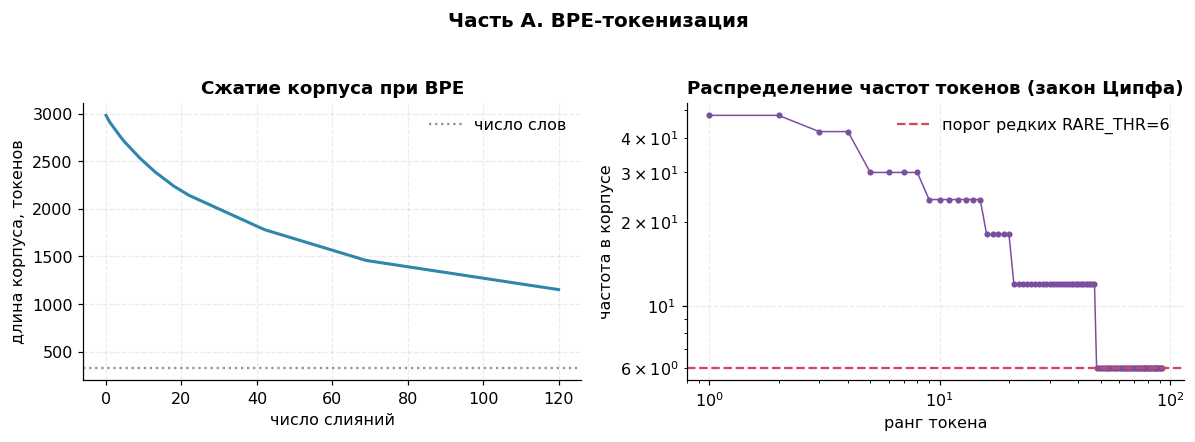

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ЛЕВАЯ ПАНЕЛЬ: как падает длина корпуса с числом слияний
ax = axes[0]
ax.plot(range(len(lengths)), lengths, color=PALETTE["attn"], lw=2)
ax.set_xlabel("число слияний")
ax.set_ylabel("длина корпуса, токенов")
ax.set_title("Сжатие корпуса при BPE")
# Пунктир — уровень "одно слово = один токен"
ax.axhline(n_words, color=PALETTE["gray"], ls=":", label="число слов")
ax.legend()

# ПРАВАЯ ПАНЕЛЬ: распределение частот в log-log (закон Ципфа)
ax = axes[1]
# Если распределение подчиняется закону Ципфа, на log-log это прямая.
ax.loglog(np.arange(1, len(freqs) + 1), freqs, "o-", ms=3,
          color=PALETTE["accent"], lw=1)
ax.axhline(RARE_THR, color=PALETTE["bad"], ls="--",
           label=f"порог редких RARE_THR={RARE_THR}")
ax.set_xlabel("ранг токена")
ax.set_ylabel("частота в корпусе")
ax.set_title("Распределение частот токенов (закон Ципфа)")
ax.legend()

finish(fig, "Часть A. BPE-токенизация")

**Вопрос A.** Во сколько раз выросла бы стоимость слоя внимания, если перейти от BPE к посимвольной
токенизации при том же тексте? Используйте измеренный коэффициент сжатия и зависимость $O(n^2)$.

**Ответ A.** Коэффициент сжатия «символы → BPE» показывает, во сколько раз BPE-последовательность короче посимвольной. Поскольку стоимость внимания O(n*n). Если перейти от BPE к посимвольной токенизации, длина n вырастет в c раз (где с - коэффициент сжатия), а стоимость внимания - в c^2 раз.  
у меня с = 2.3 следовательно длина вырастет в 2.3 раза а стоимость в 5,29

## Часть B. Затухание градиента в рекуррентной сети

Для рекуррентности $h_t = \phi(W h_{t-1} + U x_t)$ производная по состоянию, удалённому на $k$ шагов,
содержит произведение $k$ матриц:

$
\frac{\partial h_T}{\partial h_{T-k}} = \prod_{j=0}^{k-1} \operatorname{diag}(\phi')\, W .
$

Норма такого произведения ведёт себя как $\rho(W)^k$. Аддитивный путь с гейтом $f_t$ даёт вместо
этого множитель $\prod f_t$, который при $f_t \to 1$ почти не затухает.

**Задание B.1.** Вычислите норму произведения $k$ матриц с заданным спектральным радиусом.
**Задание B.2.** Постройте график нормы от $k$ для $\rho \in \{0.9, 1.0, 1.2\}$ и добавьте
аддитивные пути с $f_t = 0.99$ и $f_t = 0.95$.
**Задание B.3.** Найдите эффективный горизонт памяти: при каком $k$ норма падает ниже $10^{-6}$.

# Рекуррентная сеть: проблема дальних зависимостей

## Базовая RNN

$$
h_t = \phi(W h_{t-1} + U x_t)
$$

Где:

- $h_t$ — скрытое состояние в момент $t$
- $x_t$ — вход в момент $t$
- $W$ — матрица весов скрытого состояния
- $U$ — матрица весов входа
- $\phi$ — нелинейность (tanh, sigmoid, ReLU)

---

## Градиент через k шагов

Чтобы обучить сеть зависимости на расстоянии $k$ шагов, нужно, чтобы градиент $\partial h_T / \partial h_{T-k}$ не затух.

По правилу цепочки:

$$
\frac{\partial h_T}{\partial h_{T-k}} = \prod_{j=0}^{k-1} \operatorname{diag}(\phi')\, W
$$

Где:

- $\operatorname{diag}(\phi')$ — диагональная матрица производных нелинейности
- $W$ — матрица весов
- произведение берётся по $k$ шагам

---

## Поведение нормы произведения

Норма произведения матриц ведёт себя как $\rho(W)^k$, где $\rho(W)$ — **спектральный радиус** (максимальное по модулю собственное значение):

$$
\left\| \prod_{j=0}^{k-1} \operatorname{diag}(\phi')\, W \right\| \sim \rho(W)^k
$$

### Три режима

**$\rho < 1$:** **Затухающий градиент (vanishing).** Сеть не учится на далёких зависимостях.


**$\rho > 1$:** **Взрывной градиент (exploding).** Обучение нестабильно.


**$\rho = 1$:** Граница, но малейшее отклонение уводит в одну из крайностей.

---

## LSTM-решение

Аддитивный путь через гейт забывания:

$$
c_t = f_t \odot c_{t-1} + i_t \odot g_t
$$

Где:

- $c_t$ — состояние ячейки
- $f_t$ — гейт забывания
- $i_t$ — входной гейт
- $g_t$ — кандидат на новое значение
- $\odot$ — поэлементное умножение

Производная:

$$
\frac{\partial c_T}{\partial c_{T-k}} = \prod_{t=T-k+1}^{T} f_t
$$

Если $f_t \to 1$, затухания почти нет. Гейт обучается и может «выключаться» там, где нужно.

---

## Эффективный горизонт памяти

Условие затухания:

$$
\rho^k < \text{thr}
$$

Отсюда предельное число шагов:

$$
k^* = \frac{\log(\text{thr})}{\log(\rho)}
$$

Где:

- $\text{thr}$ — порог, ниже которого градиент считается затухшим
- $\rho$ — спектральный радиус
- $k^*$ — эффективный горизонт памяти

# Проблема дальних зависимостей в RNN

Рекуррентная сеть обновляет скрытое состояние на каждом шаге по формуле $h_t = \phi(W h_{t-1} + U x_t)$, где $h_t$ — память на шаге $t$, $x_t$ — вход, $W$ и $U$ — обучаемые матрицы, $\phi$ — нелинейность. Смысл в том, что сеть читает последовательность по одному элементу и накапливает информацию в скрытом состоянии. Чтобы предсказать что-то в конце последовательности, ей нужно дотащить туда информацию из начала.

Обучение идёт через обратное распространение градиента. Чтобы понять, как параметры, влияющие на состояние $k$ шагов назад, должны измениться, нужно посчитать градиент $\partial h_T / \partial h_{T-k}$. По правилу цепочки он равен произведению $k$ матриц: $\frac{\partial h_T}{\partial h_{T-k}} = \prod_{j=0}^{k-1} \operatorname{diag}(\phi')\, W$. Это произведение и определяет, дойдёт ли сигнал от далёкого шага до текущего.

Норма такого произведения ведёт себя как $\rho(W)^k$, где $\rho(W)$ — спектральный радиус матрицы $W$, то есть максимальное по модулю собственное значение. Если $\rho < 1$, то $\rho^k \to 0$ при росте $k$, и градиент затухает. Сеть не может обучиться на зависимостях, которые находятся далеко. Если $\rho > 1$, то $\rho^k \to \infty$, и градиент взрывается, обучение становится нестабильным. При $\rho = 1$ ситуация на границе, но любое отклонение уводит в одну из крайностей. Это фундаментальная проблема обычной RNN, и она не решается простым подбором гиперпараметров.

LSTM решает её через аддитивный путь обновления памяти. Вместо того чтобы перемножать матрицы на каждом шаге, состояние ячейки обновляется по формуле $c_t = f_t \odot c_{t-1} + i_t \odot g_t$, где $f_t$ — гейт забывания, $i_t$ — входной гейт, $g_t$ — кандидат на новое значение, $\odot$ — поэлементное умножение. Производная в этом случае равна $\frac{\partial c_T}{\partial c_{T-k}} = \prod_{t=T-k+1}^{T} f_t$. Если $f_t \to 1$, затухания почти нет, и градиент проходит через много шагов.

Ключевое отличие в том, что $f_t$ — обучаемый параметр, а не фиксированное число. Сеть сама выставляет его близким к 1 там, где информацию нужно сохранить, и близким к 0 там, где её можно стереть. Это позволяет удерживать градиент на большом числе шагов без взрыва.

Эффективный горизонт памяти определяется из условия $\rho^k < \text{thr}$, откуда $k^* = \log(\text{thr}) / \log(\rho)$. Здесь $\text{thr}$ — порог, ниже которого градиент считается затухшим, а $k^*$ — максимальное число шагов, на котором сеть ещё способна учиться. Чем ближе $\rho$ к единице, тем длиннее этот горизонт.

In [10]:
"""
make_W        →  создаёт матрицу с заданным ρ
                 (нормирует случайную матрицу)
        ↓
grad_norms    →  перемножает W саму на себя k раз
                 и измеряет норму произведения
                 проверяет: норма ≈ ρ^k
        ↓
horizon       →  по формуле считает, через сколько шагов
                 ρ^k упадёт ниже порога
                 это и есть эффективный горизонт памяти
"""

def make_W(d, rho, gen):
    """
    Создаёт случайную матрицу d×d с заданным спектральным радиусом rho.
    
    Как: генерируем случайную гауссову матрицу, нормируем на sqrt(d),
    потом домножаем на rho / max|eigval|, чтобы спектральный радиус стал ровно rho.
    """
    A = gen.normal(size=(d, d)) / np.sqrt(d)
    eigmax = np.max(np.abs(np.linalg.eigvals(A)))
    return A * rho / eigmax

def grad_norms(rho, k_max=120, d=32, seed=0):
    """
    Возвращает массив норм ||P_k||_2, где P_k = W @ W @ ... @ W (k раз).
    
    Логика: накапливаем произведение P = P @ W и на каждом шаге считаем
    спектральную норму (np.linalg.norm(P, 2) — максимальное сингулярное число).
    Ожидаем увидеть ||P_k|| ≈ rho^k.
    """
    gen = np.random.default_rng(seed)
    W = make_W(d, rho, gen)
    P = np.eye(d)                # начинаем с единичной матрицы
    norms = []
    for k in range(1, k_max + 1):
        P = P @ W                # добавляем ещё один множитель W
        norms.append(np.linalg.norm(P, 2))   # спектральная норма
    return np.array(norms)

def horizon(rho, thr=1e-6, k_max=4000, d=32, seed=0):
    """
    Эффективный горизонт: наименьшее k, при котором rho^k < thr.
    
    Аналитически: k = log(thr) / log(rho).
    Не перемножаем матрицы — при больших k это медленно и численно нестабильно.
    """
    if rho <= 0 or rho == 1.0:
        return k_max              # горизонт бесконечен
    k = math.log(thr) / math.log(rho)
    return min(k, k_max)


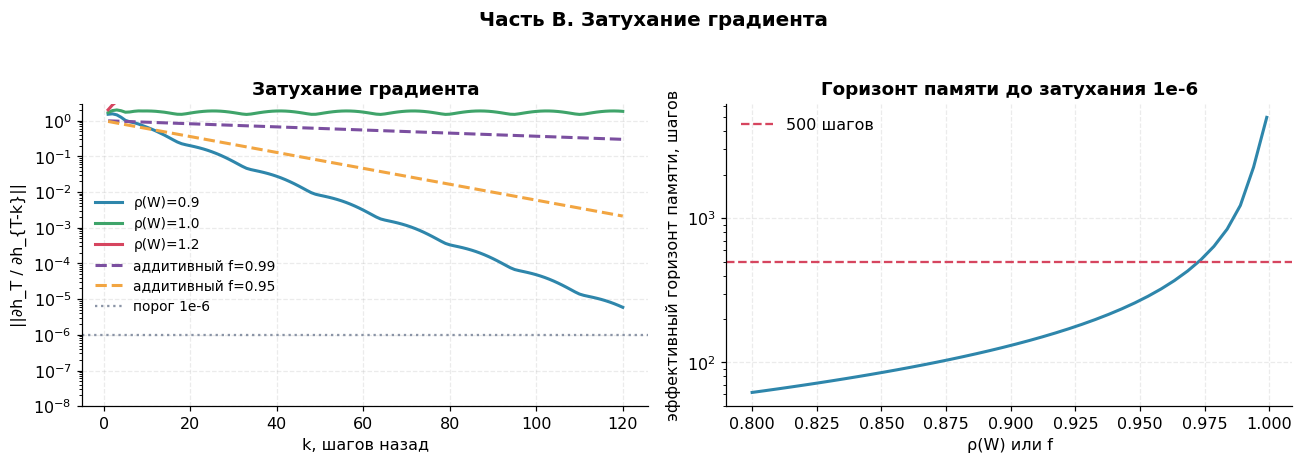

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# --- ЛЕВАЯ ПАНЕЛЬ: нормы для разных rho + аддитивный путь ---
ax = axes[0]
ks = np.arange(1, 121)   # k от 1 до 120

# Три значения rho(W): затухание, граница, взрыв
for rho, col in zip([0.9, 1.0, 1.2],
                    [PALETTE["attn"], PALETTE["good"], PALETTE["bad"]]):
    ns = grad_norms(rho, k_max=120)
    # semilogy — логарифмическая шкала по y, чтобы увидеть экспоненту
    ax.semilogy(ks, ns, lw=2, color=col, label=f"ρ(W)={rho}")

# Аддитивный путь: f^k, где f — гейт забывания LSTM
for f, col in zip([0.99, 0.95], [PALETTE["accent"], PALETTE["linear"]]):
    ax.semilogy(ks, f ** ks, ls="--", lw=2, color=col,
                label=f"аддитивный f={f}")

ax.axhline(1e-6, color=PALETTE["gray"], ls=":", label="порог 1e-6")
ax.set_xlabel("k, шагов назад")
ax.set_ylabel("||∂h_T / ∂h_{T-k}||")
ax.set_title("Затухание градиента")
ax.legend(fontsize=9)
ax.set_ylim(1e-8, 3)

# --- ПРАВАЯ ПАНЕЛЬ: горизонт памяти как функция rho ---
ax = axes[1]
rhos = np.linspace(0.8, 0.999, 40)
# Считаем горизонт для каждого rho: при каком k норма < 1e-6
hs = [horizon(r, thr=1e-6, k_max=5000) for r in rhos]
ax.semilogy(rhos, hs, lw=2, color=PALETTE["attn"])
# Отмечаем 500 шагов — типичное требование
ax.axhline(500, color=PALETTE["bad"], ls="--", label="500 шагов")
ax.set_xlabel("ρ(W) или f")
ax.set_ylabel("эффективный горизонт памяти, шагов")
ax.set_title("Горизонт памяти до затухания 1e-6")
ax.legend()

finish(fig, "Часть B. Затухание градиента")

In [30]:
k_test = 100          # на каком шаге смотрим норму
thr_horizon = 1e-6    # порог "затухания" для горизонта

print(f"Норма при k={k_test} и горизонт до {thr_horizon:.0e}:")
print(f"{'ρ(W) или f':>12} | {'Норма при k=100':>16} | {'Горизонт':>12}")
print("-" * 48)

# --- Три значения спектрального радиуса ---
for rho in [0.9, 1.0, 1.2]:
    # Норма произведения k матриц с данным rho
    # (считаем ровно k_test перемножений, чтобы получить P_k)
    ns = grad_norms(rho, k_max=k_test)
    norm_at_k = ns[-1]                # норма при k = k_test

    # Горизонт: при каком k норма падает ниже thr_horizon
    k_hor = horizon(rho, thr=thr_horizon, k_max=5000)

    # Для rho = 1.0 горизонт бесконечен, но k_max ограничивает
    if rho == 1.0:
        k_str = f"{int(k_hor)} (ограничение k_max)"
    elif rho > 1.0:
        # Взрыв — норма растёт, не затухает
        k_str = "0 (мгновенный взрыв)"
    else:
        k_str = f"{int(round(k_hor))} шагов"

    print(f"{rho:>12.2f} | {norm_at_k:>16.3e} | {k_str:>12}")

# --- Аддитивный путь f = 0.99 ---
# Норма произведения = f^k, потому что каждый множитель — скаляр f
f = 0.99
norm_f = f ** k_test
# Горизонт: f^k = thr -> k = log(thr)/log(f)
k_hor_f = math.log(thr_horizon) / math.log(f)

print(f"{'f = 0.99':>12} | {norm_f:>16.3e} | {int(round(k_hor_f)):>8} шагов")

Норма при k=100 и горизонт до 1e-06:
  ρ(W) или f |  Норма при k=100 |     Горизонт
------------------------------------------------
        0.90 |        4.822e-05 |    131 шагов
        1.00 |        1.816e+00 | 5000 (ограничение k_max)
        1.20 |        1.504e+08 | 0 (мгновенный взрыв)
    f = 0.99 |        3.660e-01 |     1375 шагов


**Вопрос B.** Пусть требуется удерживать зависимость длиной 500 шагов с ослаблением сигнала не
более чем в 10 раз. Какое значение гейта $f_t$ для этого нужно? Сравните с $\rho(W)$, необходимым в
чистой рекуррентности.

**Ответ B.** 
после 500 шагов отношение «выход / вход» должно быть **не меньше**, чем $1/10 = 0.1$.
Обозначим за $f$ коэффициент сохранения за один шаг. Тогда за 500 шагов сигнал умножается на $f^{500}$. Условие:
$$
f^{500} \geq 0.1
$$
Нужно найти минимальное $f$, при котором это выполняется.
Возводим обе стороны в степень $1/500$. Это то же самое, что извлечь корень 500-й степени:
$$
f \geq 0.1^{1/500}
$$

Логарифм и экспонента — обратные функции, поэтому:

$$
0.1^{1/500} = e^{\ln(0.1) / 500}
$$

Проверка: $e^{\ln x} = x$, значит $e^{\ln(0.1) / 500} = (0.1)^{1/500}$. 

Натуральный логарифм от 0.1:

$$
\ln(0.1) = \ln(10^{-1}) = -\ln(10) \approx -2.302585
$$

Значение $\ln 10 \approx 2.302585$ 

$$
\frac{\ln(0.1)}{500} = \frac{-2.302585}{500} \approx -0.00460517
$$

Это число — показатель степени для $e$.

$$
f \geq e^{-0.00460517}
$$

Разложение экспоненты для малых $x$: $e^x \approx 1 + x$ при $|x| \ll 1$. Здесь $x = -0.0046$, значит:

$$
e^{-0.00460517} \approx 1 - 0.00460517 = 0.99539483
$$

Более точное вычисление даёт то же самое с точностью до шестого знака:

$$
f \geq 0.9954
$$


**Для чистой рекуррентности: нужно ρ(W) ≥ 0.9954, то есть практически на границе устойчивости (ρ<1). Это экстремально трудно поддерживать при обучении: любой шум в градиентах уводит ρ либо в затухание, либо во взрыв.**

**Для аддитивного пути нужно f_t ≥ 0.9954 Гейт f_t — обучаемый параметр, он может быть близок к 1 для «удерживающих» каналов и близок к 0 для «сбрасывающих». Это даёт управляемую память без жёсткого контроля спектрального радиуса. Именно поэтому LSTM/GRU работают, а простые RNN — нет.**

## Часть C. Внимание с нуля и роль масштабирования

$
\operatorname{Attention}(Q,K,V) = \operatorname{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right) V .
$

Делитель $\sqrt{d_k}$ не косметика: при $q,k \sim \mathcal N(0,1)$ скалярное произведение имеет
дисперсию $d_k$, и без нормировки softmax при больших $d_k$ вырождается почти в one-hot, что
обнуляет градиент по ключам.

**Задание C.1.** Реализуйте одну голову внимания с каузальной маской и без неё.
**Задание C.2.** Проверьте два обязательных свойства: строки матрицы внимания суммируются в единицу,
а при каузальной маске верхний треугольник строго нулевой.
**Задание C.3.** Измерьте среднюю энтропию распределения внимания как функцию $d_k$ с делителем и
без него, постройте рисунок с картами внимания и графиком энтропии.

# Scaled dot-product attention

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

$Q$ — запросы, $K$ — ключи, $V$ — значения. $d_k$ — размерность векторов запросов и ключей.

---

# Зачем делить на $\sqrt{d_k}$

Берём вектор запроса $q$ и вектор ключа $k$, оба длины $d_k$. Их компоненты — случайные числа из нормального распределения: $q_i, k_i \sim \mathcal{N}(0, 1)$. Считаем скалярное произведение:

$$
q \cdot k = \sum_{i=1}^{d_k} q_i k_i
$$

Это сумма $d_k$ слагаемых. Каждое слагаемое $q_i k_i$ — произведение двух независимых нормальных чисел. У такого произведения дисперсия равна 1. Когда складываем $d_k$ независимых слагаемых, дисперсии складываются:

$$
\text{Var}(q \cdot k) = d_k
$$

Значит, стандартное отклонение:

$$
\sigma(q \cdot k) = \sqrt{d_k}
$$

То есть скалярное произведение в среднем имеет размер порядка $\sqrt{d_k}$. Чем больше $d_k$, тем больше разброс. При $d_k = 256$ это примерно $\pm 16$.

---

# Почему большой разброс — плохо

Логиты внимания — это как раз скалярные произведения $q \cdot k$. Дальше к ним применяется softmax. Если логиты большие по модулю, softmax становится почти one-hot: один класс забирает почти всю вероятность, остальные — около нуля.

Формально: если разница между максимумом и вторым по величине порядка 16, то отношение вероятностей:

$$
\frac{p_{\max}}{p_2} = e^{16} \approx 9 \cdot 10^6
$$

Один класс доминирует. Остальные не получают почти ничего.

---

# Почему это ломает обучение

Производная softmax:

$$
\frac{\partial p_i}{\partial s_i} = p_i (1 - p_i)
$$

Если $p_i \to 1$, то $p_i (1 - p_i) \to 0$. Градиент зануляется. Это называется **насыщение**.

Смысл: когда softmax уверен в одном классе, изменение логитов почти не меняет выход. Производная близка к нулю, обратное распространение не доносит сигнал. Обучение останавливается.

Та же проблема, что у сигмоиды на плато: градиент исчезает.

---

# Что делает деление

Делим логиты на $\sqrt{d_k}$:

$$
\tilde{s} = \frac{q \cdot k}{\sqrt{d_k}}
$$

Дисперсия нового логита:

$$
\text{Var}(\tilde{s}) = \frac{d_k}{d_k} = 1
$$

Стандартное отклонение равно 1. Разброс больше не зависит от $d_k$. Логиты порядка $\pm 1$, разница между максимумом и вторым — тоже порядка 1.

Softmax от таких логитов даёт гладкое распределение. Никто не доминирует. Производная $p_i (1 - p_i)$ не зануляется. Градиенты проходят.

---

# Почему именно $\sqrt{d_k}$

Хотим вернуть стандартное отклонение к 1. Исходное стандартное отклонение — $\sqrt{d_k}$. Значит, делить надо на $\sqrt{d_k}$.

Если делить на $d_k$, дисперсия станет $1/d_k$, стандартное отклонение — $1/\sqrt{d_k}$. Логиты сожмутся слишком сильно, softmax станет почти uniform, внимание потеряет избирательность.

$\sqrt{d_k}$ — единственный делитель, который возвращает дисперсию ровно к 1.

---

# Каузальная маска

В моделях типа GPT нельзя смотреть в будущее. Для этого перед softmax ставим $-\infty$ на позиции $j > i$:

$$
s_{ij} = -\infty \quad \text{при } j > i
$$

$i$ — текущая позиция, $j$ — та, на которую смотрим. Если $j > i$ — это будущее.

После softmax:

$$
\text{softmax}(-\infty) = 0
$$

Запрещённые позиции получают нулевой вес. Токен $i$ смотрит только на себя и прошлое.

Маска ставится до softmax, а не после. Если поставить после, веса уже распределены, и обнуление части нарушит сумму 1. А $-\infty$ до softmax автоматически даёт ноль после.

In [12]:
def attention(Q, K, V, causal=True, scale=True):
    """
    Scaled dot-product attention.
    
    Аргументы:
        Q: (T_q, d_k) — запросы
        K: (T_k, d_k) — ключи
        V: (T_k, d_v) — значения
        causal: применять ли каузальную маску (запрет будущего)
        scale: делить ли на sqrt(d_k)
    
    Возвращает:
        (output, att_matrix)
        output: (T_q, d_v)
        att_matrix: (T_q, T_k) — нормированные веса внимания
    """
    d_k = Q.shape[-1]
    
    # ШАГ 1: логиты = Q @ K^T
    # Для каждой пары (i, j) это скалярное произведение q_i · k_j
    scores = Q @ K.T
    
    # ШАГ 2: масштабирование
    # Без этого при больших d_k softmax насыщается
    if scale:
        scores = scores / math.sqrt(d_k)
    
    # ШАГ 3: каузальная маска
    # torch.triu(..., diagonal=1) — верхний треугольник БЕЗ диагонали (True выше диагонали)
    if causal:
        T = scores.shape[-1]
        mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
        # masked_fill: где mask=True, ставим -inf
        scores = scores.masked_fill(mask, float("-inf"))
    
    # ШАГ 4: стабильный softmax
    # Вычитаем максимум по строке, чтобы избежать overflow exp()
    scores = scores - scores.max(dim=-1, keepdim=True).values
    att = torch.softmax(scores, dim=-1)
    
    # ШАГ 5: взвешенная сумма значений
    return att @ V, att

def mean_entropy(d_k, scale, n=64, trials=40, seed=0):
    """
    Средняя энтропия распределения внимания для случайных Q, K размера (n, d_k).
    
    Энтропия H = -sum(p * log(p)). Максимум для n ключей = ln(n).
    Если H падает — распределение становится "пикообразным".
    """
    gen = torch.Generator().manual_seed(seed)
    ent = []
    for _ in range(trials):
        Q = torch.randn(n, d_k, generator=gen)
        K = torch.randn(n, d_k, generator=gen)
        V = torch.randn(n, 1, generator=gen)
        # Без каузальной маски, чтобы видеть эффект только масштабирования
        _, att = attention(Q, K, V, causal=False, scale=scale)
        p = att.clamp_min(1e-12)   # защита от log(0)
        # Энтропия каждой строки, потом среднее
        ent.append(float(-(p * p.log()).sum(-1).mean()))
    return float(np.mean(ent))

In [13]:
# Генерируем тестовые матрицы
g = np.random.default_rng(SEED)
Qt = torch.tensor(g.normal(size=(8, 16)), dtype=torch.float32)
Kt = torch.tensor(g.normal(size=(8, 16)), dtype=torch.float32)
Vt = torch.tensor(g.normal(size=(8, 3)),  dtype=torch.float32)

# Считаем внимание с каузальной маской
_, Wt = attention(Qt, Kt, Vt, causal=True, scale=True)

# --- C.2a: суммы по строкам должны быть равны 1 ---
row_sums = Wt.sum(dim=-1).numpy()
assert np.allclose(row_sums, 1.0, atol=1e-5), "суммы строк != 1"

# --- C.2b: верхний треугольник (будущее) должен быть строго нулевым ---
upper = torch.triu(Wt, diagonal=1).abs().max().item()
assert upper < 1e-6, "верхний треугольник не нулевой"

# --- C.2c: максимальное отклонение сумм от 1 ---
print(f"максимальное отклонение сумм строк от 1: {np.abs(row_sums - 1).max():.2e}")
print(f"максимум в верхнем треугольнике: {upper:.2e}")

максимальное отклонение сумм строк от 1: 1.19e-07
максимум в верхнем треугольнике: 0.00e+00


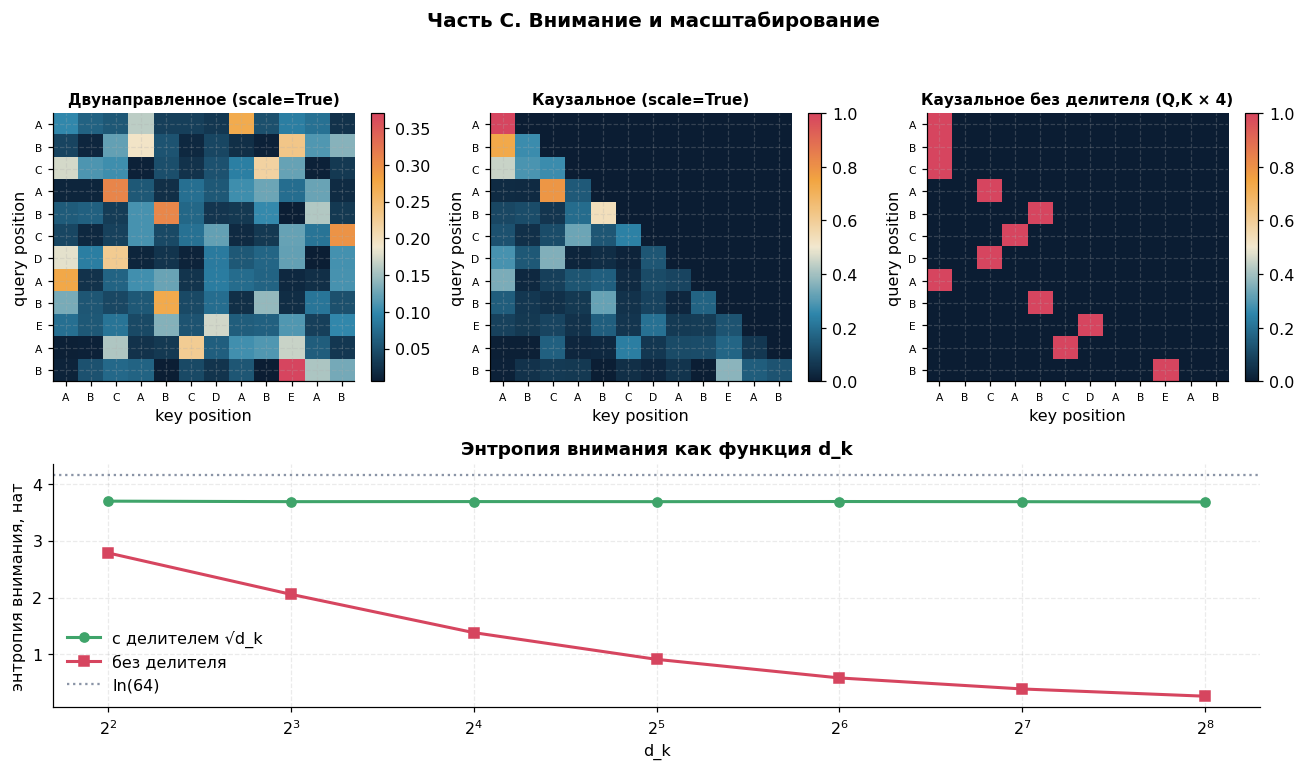

In [14]:
# Маленький пример с повторяющимися паттернами — на нём видно структуру внимания
n_tok, d_k = 12, 16
labels = ["A", "B", "C", "A", "B", "C", "D", "A", "B", "E", "A", "B"]

gen = torch.Generator().manual_seed(SEED)
Q = torch.randn(n_tok, d_k, generator=gen)
K = torch.randn(n_tok, d_k, generator=gen)
V = torch.randn(n_tok, d_k, generator=gen)

# Три варианта внимания
_, att_bi = attention(Q, K, V, causal=False, scale=True)          # двунаправленное
_, att_ca = attention(Q, K, V, causal=True,  scale=True)          # каузальное
_, att_no = attention(Q * 4, K * 4, V, causal=True, scale=False)  # без делителя, увеличенные Q,K

# --- Рисуем ---
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 3, height_ratios=[1.1, 1])

# Верхний ряд: три тепловые карты внимания
for i, (att, ttl) in enumerate(zip(
        [att_bi, att_ca, att_no],
        ["Двунаправленное (scale=True)",
         "Каузальное (scale=True)",
         "Каузальное без делителя (Q,K × 4)"])):
    ax = fig.add_subplot(gs[0, i])
    im = ax.imshow(att.numpy(), cmap=CMAP_HEAT, aspect="auto")
    ax.set_title(ttl, fontsize=10)
    ax.set_xlabel("key position")
    ax.set_ylabel("query position")
    ax.set_xticks(range(n_tok)); ax.set_xticklabels(labels, fontsize=7)
    ax.set_yticks(range(n_tok)); ax.set_yticklabels(labels, fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046)

# Нижний ряд: энтропия внимания от d_k
dks = [4, 8, 16, 32, 64, 128, 256]
ent_s = [mean_entropy(d, True,  seed=SEED) for d in dks]   # с делителем
ent_n = [mean_entropy(d, False, seed=SEED) for d in dks]   # без делителя

ax = fig.add_subplot(gs[1, :])
ax.plot(dks, ent_s, "o-", lw=2, color=PALETTE["good"], label="с делителем √d_k")
ax.plot(dks, ent_n, "s-", lw=2, color=PALETTE["bad"],  label="без делителя")
# ln(64) — максимальная энтропия для 64 ключей
ax.axhline(math.log(64), color=PALETTE["gray"], ls=":", label="ln(64)")
ax.set_xscale("log", base=2)
ax.set_xlabel("d_k"); ax.set_ylabel("энтропия внимания, нат")
ax.set_title("Энтропия внимания как функция d_k")
ax.legend()

finish(fig, "Часть C. Внимание и масштабирование")

In [15]:
# Таблица значений энтропии
print("Энтропия внимания (нат):")
print(f"{'d_k':>5} | {'с делителем':>12} | {'без делителя':>12}")
for d, es, en in zip(dks, ent_s, ent_n):
    print(f"{d:>5} | {es:>12.3f} | {en:>12.3f}")

Энтропия внимания (нат):
  d_k |  с делителем | без делителя
    4 |        3.694 |        2.784
    8 |        3.685 |        2.057
   16 |        3.686 |        1.383
   32 |        3.685 |        0.913
   64 |        3.687 |        0.587
  128 |        3.684 |        0.393
  256 |        3.680 |        0.266


**Вопрос C.** Почему вырождение softmax в one-hot останавливает обучение? Свяжите ответ с
производной softmax по логитам.


Обучение нейросети работает так: модель делает предсказание, считается ошибка, потом вычисляется **градиент** — число, показывающее, в какую сторону и насколько нужно изменить каждый вес, чтобы ошибка уменьшилась. Если градиент равен нулю — веса не меняются, обучение стоит на месте.

Внимание работает через softmax. Softmax берёт числа (логиты) и превращает их в вероятности. Производная softmax показывает, **насколько изменится вероятность, если изменить логит**.

Формула производной:

$$
\frac{\partial p_i}{\partial s_j} = p_i (\delta_{ij} - p_j)
$$

Здесь $p_i$ — вероятность класса $i$, $p_j$ — вероятность класса $j$, $\delta_{ij}$ — это 1, если $i = j$, и 0 иначе.

Дальше смотрим, что происходит, когда softmax выдаёт **one-hot** — то есть одна вероятность почти 1, остальные почти 0.

Пусть класс $i$ — доминирующий, то есть $p_i \approx 1$. Остальные $p_j \approx 0$.

Подставляем в формулу:

**Случай $i = j$** (меняем логит самого доминирующего класса):

$$
p_i (1 - p_i) \approx 1 \cdot (1 - 1) = 1 \cdot 0 = 0
$$

**Случай $i \neq j$** (меняем логит другого класса):

$$
-p_i p_j \approx -1 \cdot 0 = 0
$$

Все производные равны нулю. Это значит: **что бы мы ни делали с логитами, вероятности не изменятся**. Softmax уже «упёрся в потолок».

Градиент по весам $Q$ и $K$ проходит через softmax. Раз производная softmax равна нулю — градиент по $Q$ и $K$ тоже равен нулю. Веса не обновляются. Модель застревает. Обучение останавливается.

Именно поэтому логиты делят на $\sqrt{d_k}$. Без деления логиты большие, softmax насыщается, производные зануляются. С делением логиты маленькие, softmax не насыщается, производные не нулевые, обучение идёт.

## Часть D. Позиционные кодировки: синусоида, RoPE, ALiBi

Внимание перестановочно инвариантно, поэтому порядок вносится отдельно:

- синусоидальная кодировка добавляется к эмбеддингу (абсолютная позиция);
- **RoPE** поворачивает $q$ и $k$ на угол, пропорциональный позиции, так что
  $\langle R_t q, R_s k\rangle = f(q,k,t-s)$;
- **ALiBi** добавляет к логитам линейный штраф $-m|t-s|$.

**Задание D.1.** Реализуйте синусоидальную кодировку.
**Задание D.2.** Реализуйте RoPE и численно проверьте зависимость только от $t-s$: постройте
$\langle R_{t}q, R_{s}k\rangle$ для нескольких абсолютных начал при одинаковых разностях позиций.
**Задание D.3.** Постройте матрицу штрафов ALiBi для одной головы и рисунок из трёх панелей.

# Позиционное кодирование

## Проблема: внимание перестановочно инвариантно

Механизм внимания не различает порядок токенов. Если переставить токены местами, веса внимания просто переставятся, а сумма не изменится. То есть без позиционной информации модель не отличит «А ударил Б» от «Б ударил А» — для неё это одна и та же последовательность.

Чтобы это исправить, в модель добавляют информацию о позиции токена. Есть три подхода.

---

## Синусоидальная кодировка (Vaswani 2017)

Позиционный вектор добавляется к эмбеддингу токена. Формула:

$$
PE_{pos,\, 2i} = \sin\!\left(\frac{pos}{10000^{2i/d}}\right)
$$

$$
PE_{pos,\, 2i+1} = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)
$$

Где $pos$ — позиция токена, $i$ — индекс размерности, $d$ — размерность эмбеддинга.

Чётные размерности заполняются синусами, нечётные — косинусами. Частота меняется от размерности к размерности: для малых $i$ частота высокая, для больших — низкая. Это даёт многомасштабное представление позиции.

Кодировка **абсолютная** и **фиксированная** — она не обучается. Для каждой позиции вектор вычисляется по формуле и добавляется к эмбеддингу перед подачей в модель.

---

## RoPE (Su 2021)

RoPE — Rotary Position Embedding. Идея другая: позиция кодируется не добавлением, а **поворотом** векторов $q$ и $k$ на угол, пропорциональный позиции.

Пусть $q$ и $k$ — векторы запроса и ключа. К ним применяется поворот:

$$
\tilde{q} = R_t \, q, \quad \tilde{k} = R_s \, k
$$

Где $R_t$ и $R_s$ — матрицы поворота, зависящие от позиций $t$ и $s$.

Ключевое свойство: скалярное произведение повёрнутых векторов зависит **только от относительной позиции** $\Delta = t - s$:

$$
\langle R_t q, \; R_s k \rangle = f(q, k, t - s)
$$

Это значит: внимание видит не «этот токен на позиции 5, тот на позиции 3», а «этот токен на 2 позиции раньше того». Относительная позиция — то, что важно для языка.

Применяется **внутри attention** — прямо к $q$ и $k$, а не к эмбеддингу. Это принципиальное отличие от синусоидальной кодировки.

---

## ALiBi (Press 2021)

ALiBi — Attention with Linear Biases. Позиция кодируется не добавлением и не поворотом, а **штрафом к логитам внимания**.

К сырым логитам $s_{ij} = q_i \cdot k_j$ добавляется линейный штраф:

$$
s_{ij} \mathrel{-}= m_h \, |t - s|
$$

Где:

- $t$ — позиция запроса, $s$ — позиция ключа
- $|t - s|$ — расстояние между ними
- $m_h$ — наклон, свой для каждой головы внимания

Чем дальше ключ от запроса, тем больше штраф, тем меньше вес внимания. Это автоматически даёт принцип «близкие токены важнее далёких».

ALiBi **не требует обучения** — наклоны $m_h$ задаются фиксированно (например, геометрической прогрессией). Штраф добавляется прямо к логитам перед softmax.

---

## Сравнение подходов

| Подход | Как кодирует | Где применяется | Обучается |
|---|---|---|---|
| Синусоидальная | добавление к эмбеддингу | до attention | нет |
| RoPE | поворот $q$ и $k$ | внутри attention | нет |
| ALiBi | штраф к логитам | внутри attention | нет |

---

## Экстраполяция на невиданные позиции

Все три подхода определены формулой для любой позиции. Но ведут они себя по-разному, когда модель встречает позиции, которых не было в обучении.

**Синусоидальная.** Формула определена для любой позиции. Но модель обучена на конкретных позициях, и «смысл» векторов для новых позиций может не совпадать с тем, что модель выучила. Экстраполяция плохая.

**RoPE.** Зависит только от относительной позиции $\Delta = t - s$. Паттерны те же, что в обучении, потому что модель выучила зависимости от $\Delta$, а не от абсолютных позиций. Можно расширять контекст — например, через NTK-aware scaling, который подстраивает частоты поворота под новую длину.

**ALiBi.** Штраф линеен и определён для любой $\Delta$. Работает на длинах, которых не было в обучении, потому что зависимость от расстояния монотонна и не привязана к конкретным абсолютным значениям позиций.

RoPE: скалярные произведения при одинаковой разности позиций Δ=5:
  начало t=  0: <R_(t+5)q, R_t k> = -3.122323
  начало t= 10: <R_(t+5)q, R_t k> = -3.122323
  начало t=100: <R_(t+5)q, R_t k> = -3.122323
  максимальное расхождение: 4.44e-16


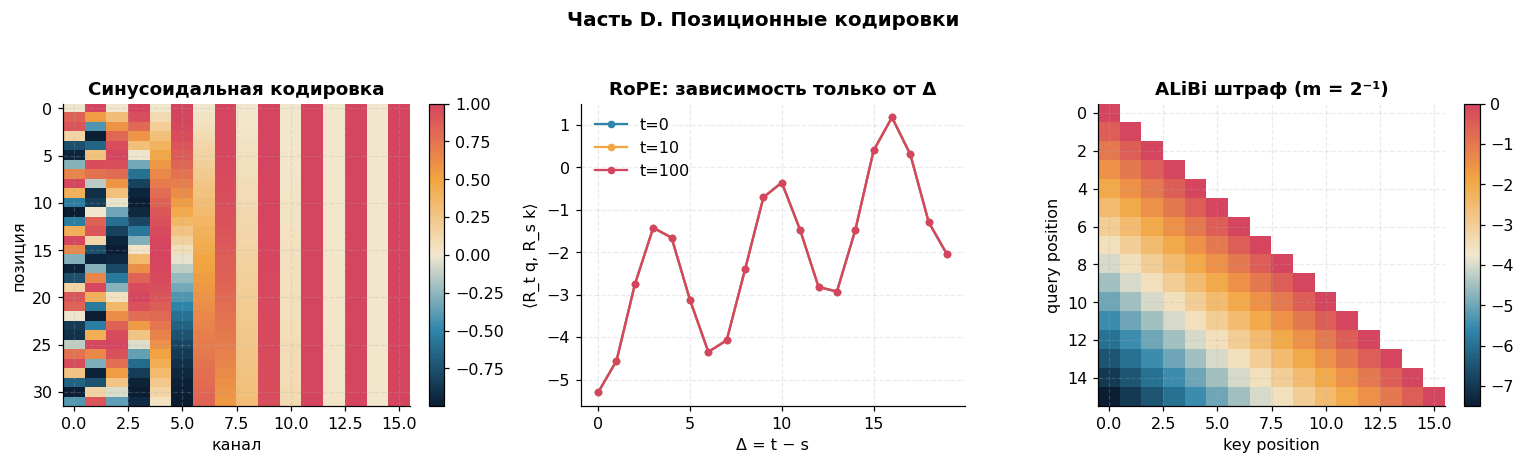

In [16]:
def sinusoidal(n, d):
    """
    Синусоидальная позиционная кодировка из "Attention Is All You Need".
    
    Аргументы:
        n: число позиций (длина последовательности)
        d: размерность эмбеддинга (должна быть чётной)
    
    Возвращает:
        pe: (n, d) — матрица позиционных кодировок
    
    Формула:
        pe[pos, 2i]   = sin(pos / 10000^(2i/d))
        pe[pos, 2i+1] = cos(pos / 10000^(2i/d))
    
    Идея: разные каналы имеют разную "частоту" — маленькие i дают
    быстро осциллирующие компоненты (локальная позиция),
    большие i — медленно меняющиеся (глобальная позиция).
    """
    pos = np.arange(n)[:, None]              # (n, 1)
    i = np.arange(0, d, 2)[None, :]          # (1, d/2) — чётные индексы
    denom = 10000 ** (i / d)                 # (1, d/2)
    pe = np.zeros((n, d))
    pe[:, 0::2] = np.sin(pos / denom)        # чётные каналы — sin
    pe[:, 1::2] = np.cos(pos / denom)        # нечётные — cos
    return pe


def rope_apply(x, pos, base=10000.0):
    """
    Применяет RoPE к вектору x в позиции pos.
    
    Аргументы:
        x: (T, d) — матрица векторов (например, Q или K)
        pos: (T,) — позиция каждого вектора
        base: база для частот (обычно 10000)
    
    Возвращает:
        x_rot: (T, d) — повёрнутые векторы
    
    Как работает:
    Разбиваем d каналов на пары (i, i+d/2). Для каждой пары
    поворачиваем на угол theta_i = pos / base^(2i/d):
        x1' = x1 * cos(theta) - x2 * sin(theta)
        x2' = x1 * sin(theta) + x2 * cos(theta)
    
    Ключевое свойство: <R_t q, R_s k> зависит только от (t-s).
    """
    T, d = x.shape
    assert d % 2 == 0, "d должно быть чётным"
    half = d // 2
    
    # Частоты для каждой пары каналов
    i = np.arange(half)[None, :]             # (1, d/2)
    # theta[t, i] = pos[t] / base^(2i/d)
    theta = pos[:, None] / (base ** (2 * i / d))
    
    cos, sin = np.cos(theta), np.sin(theta)
    
    # Первая половина каналов и вторая половина
    x1 = x[:, :half]
    x2 = x[:, half:]
    
    # Формулы поворота
    x1_new = x1 * cos - x2 * sin
    x2_new = x1 * sin + x2 * cos
    
    # Склеиваем обратно
    return np.concatenate([x1_new, x2_new], axis=-1)


# ПРОВЕРКА ИНВАРИАНТНОСТИ К СДВИГУ
gen = np.random.default_rng(SEED)
d_demo = 16
q = gen.normal(size=d_demo)
k = gen.normal(size=d_demo)

# Проверяем: при одинаковой разности позиций Δ=5 скалярное произведение
# должно быть одинаковым независимо от абсолютных позиций.
print("RoPE: скалярные произведения при одинаковой разности позиций Δ=5:")
dots = []
for t0 in [0, 10, 100]:
    # q в позиции t0+5, k в позиции t0
    qp = rope_apply(q[None, :], np.array([t0 + 5]))[0]
    kp = rope_apply(k[None, :], np.array([t0]))[0]
    dot = float(qp @ kp)
    dots.append(dot)
    print(f"  начало t={t0:>3}: <R_(t+5)q, R_t k> = {dot:+.6f}")

print(f"  максимальное расхождение: {max(dots) - min(dots):.2e}")


# Синусоидальная кодировка для отображения
pe = sinusoidal(32, 16)

# ALiBi: штрафы для нескольких голов
slopes = [2 ** (-h) for h in range(4)]    # m_h = 2^(-h) — стандарт из статьи
T = 16
alibi = np.zeros((len(slopes), T, T))
for h, m in enumerate(slopes):
    for i in range(T):
        for j in range(T):
            alibi[h, i, j] = -m * abs(i - j)
    # Запрет будущего: ставим NaN, чтобы на графике было видно "дыру"
    alibi[h] = np.where(np.triu(np.ones((T, T)), 1) > 0, np.nan, alibi[h])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# Панель 1: синусоидальная кодировка
ax = axes[0]
im = ax.imshow(pe, aspect="auto", cmap=CMAP_HEAT)
ax.set_xlabel("канал"); ax.set_ylabel("позиция")
ax.set_title("Синусоидальная кодировка")
plt.colorbar(im, ax=ax, fraction=0.046)

# Панель 2: RoPE — зависимость от Δ при разных абсолютных началах
ax = axes[1]
for t0, col in zip([0, 10, 100],
                   [PALETTE["attn"], PALETTE["linear"], PALETTE["bad"]]):
    ds = np.arange(0, 20)
    vals = [float(rope_apply(q[None, :], np.array([t0 + d]))[0]
                  @ rope_apply(k[None, :], np.array([t0]))[0]) for d in ds]
    ax.plot(ds, vals, "o-", ms=4, color=col, label=f"t={t0}")
ax.set_xlabel("Δ = t − s"); ax.set_ylabel("⟨R_t q, R_s k⟩")
ax.set_title("RoPE: зависимость только от Δ")
ax.legend()

# Панель 3: ALiBi для одной головы (h=1, m=0.5)
ax = axes[2]
im = ax.imshow(alibi[1], aspect="auto", cmap=CMAP_HEAT)
ax.set_xlabel("key position"); ax.set_ylabel("query position")
ax.set_title("ALiBi штраф (m = 2⁻¹)")
plt.colorbar(im, ax=ax, fraction=0.046)

finish(fig, "Часть D. Позиционные кодировки")

**Вопрос D.** Какая из трёх схем позволяет работать с позициями, которых не было в обучении, и
почему? Что произойдёт с обучаемой абсолютной кодировкой при выходе за максимальную длину?



**Ответ D.** Из трёх схем с позициями, которых не было в обучении, лучше всех работают RoPE и ALiBi. RoPE зависит только от разности позиций $\Delta = t - s$, а не от абсолютных значений, поэтому паттерны внимания остаются теми же, что и при обучении, и модель может работать на более длинных последовательностях. ALiBi добавляет к логитам линейный штраф, зависящий только от расстояния между токенами, и этот штраф определён для любой длины, поэтому тоже хорошо переносится на невиданные позиции. Синусоидальная кодировка формулой тоже определена для любой позиции, но модель обучалась на конкретных абсолютных позициях, и смысл векторов для новых позиций может не совпадать с выученным, поэтому экстраполяция у неё плохая. А вот обучаемая абсолютная кодировка, где для каждой позиции заводится свой обучаемый вектор, при выходе за максимальную длину просто не имеет вектора для новых позиций — их не было в словаре, и модель не может их представить.

## Часть E. Мини-трансформер и индукционная голова

Задача **ассоциативного вспоминания**: последовательность пар «ключ, значение», затем повтор одного
из ключей; модель должна выдать соответствующее значение:

$
k_1\,v_1\,k_2\,v_2\,\dots\,k_N\,v_N\ \ k_i \;\longrightarrow\; v_i .
$

Минимальное решение — схема из двух слоёв (индукционная голова): первый слой переносит в позицию
ключа информацию о следующем токене, второй сравнивает финальный запрос с ключами.

**Задание E.1.** Реализуйте блок трансформера: пред-нормализация, одна голова каузального внимания,
FFN, остаточные связи.
**Задание E.2.** Обучите модель (обучение идёт на 2…`N_MAX` парах) и измерьте точность для
2…20 пар, включая длины больше обучающих.
**Задание E.3.** Постройте карты внимания обоих слоёв для одного примера и найдите индукционную
схему.

# Задача ассоциативного вспоминания (induction head)

## Постановка задачи

Дана последовательность пар «ключ-значение»:

$$
k_1 v_1 \; k_2 v_2 \; \ldots \; k_N v_N
$$

Затем повтор одного из ключей, и модель должна выдать соответствующее значение:

$$
k_i \to v_i
$$

Пример. Пусть ключи — это буквы, значения — цифры:

```
A 1  B 2  C 3  D 4  ...  B → ?
```

Модель должна ответить `2`, потому что раньше в последовательности была пара `B 2`.

Это задача **ассоциативного вспоминания**: найти в прошлом позицию, где встречался такой же ключ, и извлечь оттуда связанное значение.

---

## Минимальное решение: два слоя внимания

Оказывается, для решения этой задачи достаточно **двух слоёв внимания**. Такая конструкция называется **индукционной головой** (induction head).

### Слой 1: голова «предыдущего токена»

На этом слое каждая позиция записывает информацию о **следующем** токене. В позиции $k_j$ сохраняется информация о $v_j$. Это операция **copy-previous** — сдвиг информации на одну позицию вправо.

После первого слоя в позиции ключа $k_j$ лежит не только сам ключ, но и «отпечаток» значения $v_j$, которое шло сразу за ним.

### Слой 2: индукционная голова

На этом слое финальный запрос $k_i$ сравнивает себя со **всеми** предыдущими ключами. Где находится такой же ключ — там активируется внимание. Из этих позиций извлекается информация, перенесённая первым слоем (то есть значение $v_j$).

Итог: модель нашла позицию, где ключ совпал, и вытащила оттуда значение. Задача решена.

---

## Почему одного слоя недостаточно

Одна голова внимания **не может одновременно** делать две вещи:

**1. Match.** Искать позиции, где ключ совпадает с текущим запросом.

**2. Copy-previous.** Копировать значение из **следующей** позиции.

Это две **разные** операции. Первая требует сравнения по сходству, вторая — сдвига информации. Совместить их в одной голове нельзя, потому что внимание по своей природе делает **одно** взвешенное суммирование: либо ищем по сходству, либо копируем — но не то и другое одновременно.

Двухслойная модель справляется потому, что каждая операция делается **отдельно**: первый слой делает copy-previous, второй — match-and-copy.

---

## Почему это важно: in-context learning

Индукционные головы — предполагаемый механизм **in-context learning**. Это ситуация, когда модель «понимает» паттерн из нескольких примеров **прямо в промпте**, без обновления весов.

Пример. Ты пишешь модели:

```
A 1  B 2  C 3  D 4  ...  B → ?
```

Модель никогда не обучалась именно на этой последовательности. Но она видит паттерн «ключ-значение», находит в контексте пару `B 2` и отвечает `2`. Это и есть обучение по контексту.

Индукционная голова объясняет, **как** это происходит: два слоя внимания выполняют match и copy, и модель может «вспомнить» нужное значение из промпта.

---


In [17]:
# Словарь задачи:
# - 256 "ключей" (индексы 0..255)
# - 16 "значений" (индексы 256..271) — по одному на каждый ключ
N_KEYS, N_VALS = 256, 16
VOCAB = N_KEYS + N_VALS

def make_recall_batch(bs, n_pairs, gen):
    """
    Генерирует батч задачи ассоциативного вспоминания.
    
    Формат одной последовательности:
        [k_0, v_0, k_1, v_1, ..., k_{n-1}, v_{n-1}, q]
    где q = один из ключей. Цель — соответствующее значение.
    
    Аргументы:
        bs: batch size
        n_pairs: сколько пар в последовательности
        gen: torch.Generator для воспроизводимости
    
    Возвращает:
        seq: (bs, 2n+1) — последовательность
        targets: (bs,) — правильные значения
        qi: (bs,) — индекс пары, из которой взят запрос
    """
    # Случайные ключи без повторений (randperm + срез)
    keys = torch.stack([torch.randperm(N_KEYS, generator=gen)[:n_pairs]
                        for _ in range(bs)])
    # Случайные значения из диапазона [N_KEYS, VOCAB)
    vals = torch.randint(N_KEYS, VOCAB, (bs, n_pairs), generator=gen)
    
    # Собираем последовательность: [k0, v0, k1, v1, ...] + финальный запрос
    seq = torch.zeros(bs, 2 * n_pairs + 1, dtype=torch.long)
    seq[:, 0:2 * n_pairs:2] = keys     # чётные позиции — ключи
    seq[:, 1:2 * n_pairs:2] = vals     # нечётные — значения
    
    # Финальный запрос — случайный ключ из уже встречавшихся
    qi = torch.randint(0, n_pairs, (bs,), generator=gen)
    seq[:, -1] = keys[torch.arange(bs), qi]
    
    return seq, vals[torch.arange(bs), qi], qi

class Block(nn.Module):
    """
    Один блок трансформера: pre-norm + каузальное внимание + FFN + residual.
    
    Архитектура (pre-norm, как в GPT-2):
        x = LN(h)
        a = Attention(x)         — одна голова каузального внимания
        h = h + Linear(a)        — residual
        h = h + FFN(LN(h))       — ещё residual
    """
    def __init__(self, d):
        super().__init__()
        self.d = d
        # Проекции для Q, K, V, O (без bias — стандарт для трансформеров)
        self.q = nn.Linear(d, d, bias=False)
        self.k = nn.Linear(d, d, bias=False)
        self.v = nn.Linear(d, d, bias=False)
        self.o = nn.Linear(d, d, bias=False)
        # LayerNorm перед attention и перед FFN
        self.ln1 = nn.LayerNorm(d)
        self.ln2 = nn.LayerNorm(d)
        # FFN: расширение в 4 раза, GELU, сжатие обратно
        self.ff = nn.Sequential(
            nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d)
        )

    def forward(self, h, ret=False):
        """
        Аргументы:
            h: (B, T, d) — входные эмбеддинги
            ret: если True — вернуть также матрицу внимания
        
        Возвращает:
            h_new: (B, T, d)
            att (опционально): (B, T, T) — веса внимания
        """
        # --- Pre-norm: нормализуем ДО attention, а не после ---
        x = self.ln1(h)
        T = h.shape[1]
        
        # Проекции Q, K, V
        q = self.q(x)                       # (B, T, d)
        k = self.k(x)                       # (B, T, d)
        v = self.v(x)                       # (B, T, d)
        
        # --- Каузальное внимание на torch ---
        # scores[b, i, j] = q[b,i] · k[b,j] / sqrt(d)
        s = q @ k.transpose(1, 2) / math.sqrt(self.d)   # (B, T, T)
        
        # Маска: True там, где j > i (будущее)
        mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
        # Ставим -inf в запрещённые позиции
        s = s.masked_fill(mask, float("-inf"))
        
        # Softmax по последней оси (по ключам)
        att = s.softmax(-1)                 # (B, T, T)
        
        # Взвешенная сумма значений
        a = att @ v                         # (B, T, d)
        
        # --- Остаточные связи ---
        h = h + self.o(a)                   # residual после attention
        h = h + self.ff(self.ln2(h))        # residual после FFN
        
        return (h, att) if ret else h

class TinyTransformer(nn.Module):
    """
    Мини-трансформер: эмбеддинг + позиционное кодирование + N блоков + голова.
    
    Для задачи recall нужна только последняя позиция — берём logits[:, -1, :].
    """
    def __init__(self, d=64, max_len=90, n_layers=2):
        super().__init__()
        # Эмбеддинг токенов
        self.emb = nn.Embedding(VOCAB, d)
        # Обучаемое абсолютное позиционное кодирование
        self.pos = nn.Embedding(max_len, d)
        # Стек блоков
        self.blocks = nn.ModuleList([Block(d) for _ in range(n_layers)])
        # Финальный LayerNorm и линейная голова на словарь
        self.lnf = nn.LayerNorm(d)
        self.head = nn.Linear(d, VOCAB)

    def forward(self, x, ret=False):
        """
        Аргументы:
            x: (B, T) — токены
            ret: если True — вернуть карты внимания всех слоёв
        
        Возвращает:
            logits_last: (B, VOCAB) — логиты последней позиции
            maps (опционально): список матриц внимания
        """
        # Сумма эмбеддингов токенов и позиций
        h = self.emb(x) + self.pos(torch.arange(x.shape[1]))
        maps = []
        for b in self.blocks:
            out = b(h, ret)
            if ret:
                h, a = out
            else:
                h, a = out, None
            maps.append(a)
        # Логиты считаем только для последней позиции (нужен ответ на запрос)
        logits = self.head(self.lnf(h)[:, -1])
        return (logits, maps) if ret else logits

print("размер словаря задачи:", VOCAB, "| случайное угадывание: %.3f" % (1 / N_VALS))

размер словаря задачи: 272 | случайное угадывание: 0.062


In [18]:
def train_recall(steps=2600, bs=64, lr=2e-3, seed=0, n_max=8):
    """
    Обучает мини-трансформер на задаче recall.
    
    Ключевая деталь: на каждом шаге n_pairs случайно из [2, n_max],
    чтобы модель видела разные длины и обобщала.
    """
    torch.manual_seed(seed)
    gen = torch.Generator().manual_seed(seed)
    m = TinyTransformer(d=D_MODEL)
    # AdamW с weight decay — стандарт для трансформеров
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=0.01)
    # OneCycleLR: сначала разогрев, потом плавное снижение
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, total_steps=steps, pct_start=0.15
    )
    curve = []
    for s in range(steps):
        # Случайная длина последовательности в [2, n_max]
        n = int(torch.randint(2, n_max + 1, (1,), generator=gen))
        x, y, _ = make_recall_batch(bs, n, gen)
        
        # Forward
        logits = m(x)                        # (bs, VOCAB)
        loss = F.cross_entropy(logits, y)
        
        # Backward
        opt.zero_grad()
        loss.backward()
        # Клиппинг градиента — защита от взрыва (частая проблема трансформеров)
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
        sched.step()
        
        # Логируем каждые 100 шагов
        if s % 100 == 0:
            curve.append((s, float(loss.item())))
    return m, curve, gen

def acc_vs_pairs(m, gen, ns, bs=256):
    """
    Считает точность для каждой длины n из списка ns.
    Модель переводится в eval(), градиенты отключены.
    """
    m.eval()
    res = []
    with torch.no_grad():
        for n in ns:
            x, y, _ = make_recall_batch(bs, n, gen)
            logits = m(x)
            acc = (logits.argmax(-1) == y).float().mean().item()
            res.append(acc)
    m.train()
    return res

# --- Запускаем обучение ---
NS = [2, 4, 6, 8, 10, 12, 16, 20]
t0 = time.time()
model, curve, gen_m = train_recall(seed=SEED, n_max=N_MAX)
acc = acc_vs_pairs(model, gen_m, NS)
train_time = time.time() - t0
print("обучение заняло %.0f c" % train_time)
print("точность по числу пар:", dict(zip(NS, [round(a, 3) for a in acc])))

обучение заняло 68 c
точность по числу пар: {2: 1.0, 4: 1.0, 6: 1.0, 8: 1.0, 10: 0.77, 12: 0.648, 16: 0.535, 20: 0.402}


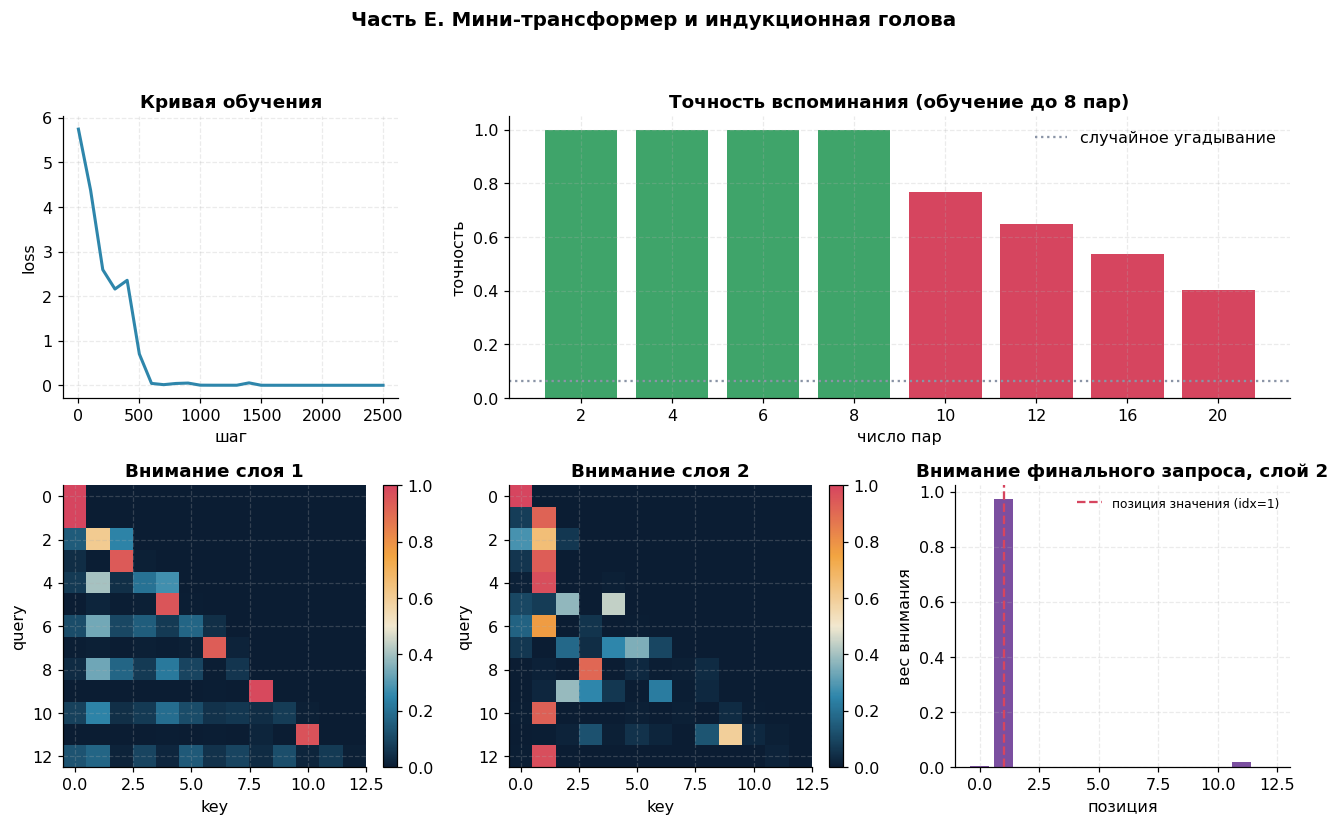

Масса внимания финального запроса на позиции значения: 0.974


In [19]:
# Один пример для визуализации внимания
x_ex, y_ex, qi_ex = make_recall_batch(1, 6, torch.Generator().manual_seed(123))
with torch.no_grad():
    logits_ex, maps = model(x_ex, ret=True)
# maps — список из двух матриц (B=1, T, T), приводим к (T, T)
maps_np = [m[0].numpy() for m in maps]

# Позиция значения, соответствующего финальному запросу:
# последовательность [k0, v0, k1, v1, ..., k5, v5, q]
# значение для q находится на позиции 2*qi+1
val_pos = 2 * int(qi_ex) + 1
attn_on_val_layer2 = maps_np[1][-1, val_pos]

fig = plt.figure(figsize=(12, 7.5))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1])

# --- Кривая обучения ---
ax = fig.add_subplot(gs[0, 0])
ax.plot([c[0] for c in curve], [c[1] for c in curve], lw=2, color=PALETTE["attn"])
ax.set_xlabel("шаг"); ax.set_ylabel("loss"); ax.set_title("Кривая обучения")

# --- Точность от числа пар ---
ax = fig.add_subplot(gs[0, 1:])
# Красные столбцы — длины БОЛЬШЕ обучающих (проверка обобщения)
cols = [PALETTE["bad"] if n > N_MAX else PALETTE["good"] for n in NS]
ax.bar([str(n) for n in NS], acc, color=cols)
ax.axhline(1 / N_VALS, color=PALETTE["gray"], ls=":", label="случайное угадывание")
ax.set_xlabel("число пар"); ax.set_ylabel("точность")
ax.set_title(f"Точность вспоминания (обучение до {N_MAX} пар)")
ax.legend()

# --- Карты внимания обоих слоёв ---
for li, mp in enumerate(maps_np):
    ax = fig.add_subplot(gs[1, li])
    im = ax.imshow(mp, cmap=CMAP_HEAT, aspect="auto")
    ax.set_title(f"Внимание слоя {li+1}")
    ax.set_xlabel("key"); ax.set_ylabel("query")
    plt.colorbar(im, ax=ax, fraction=0.046)

# --- Внимание финального запроса (слой 2) ---
ax = fig.add_subplot(gs[1, 2])
ax.bar(range(len(maps_np[1][-1])), maps_np[1][-1], color=PALETTE["accent"])
ax.axvline(val_pos, color=PALETTE["bad"], ls="--",
           label=f"позиция значения (idx={val_pos})")
ax.set_xlabel("позиция"); ax.set_ylabel("вес внимания")
ax.set_title("Внимание финального запроса, слой 2")
ax.legend(fontsize=8)

finish(fig, "Часть E. Мини-трансформер и индукционная голова")
print(f"Масса внимания финального запроса на позиции значения: {attn_on_val_layer2:.3f}")

**Вопрос E.** Почему для этой задачи недостаточно одного слоя внимания? Опишите, какую информацию
переносит первый слой и что именно сравнивает второй.

**Ответ E.** Одного слоя внимания недостаточно, потому что задача требует двух разных операций, которые одна голова выполнить не может. Первый слой выполняет copy-previous: в позиции ключа $k_j$ он записывает информацию о значении $v_j$, которое стоит сразу за ним. Это операция сдвига информации на одну позицию — она не ищет совпадений, а просто переносит содержимое соседнего токена. Второй слой выполняет match-and-copy: финальный запрос $k_i$ сравнивает себя со всеми предыдущими ключами и находит позицию, где встречался такой же ключ. Из этой позиции он извлекает значение, которое туда перенёс первый слой. Одна голова не может одновременно искать по сходству ключа и копировать значение из соседней позиции — это две разные операции, требующие разного механизма внимания. Поэтому нужны два слоя: первый готовит информацию, второй её находит и извлекает.

## Часть F. Линейное внимание: состояние вместо матрицы внимания

Если заменить $\exp(q^\top k)$ на $\varphi(q)^\top \varphi(k)$ с неотрицательным $\varphi$, сумму
можно переставить и получить рекуррентную форму с состоянием фиксированного размера:

$
S_t = S_{t-1} + \varphi(k_t) v_t^{\top}, \qquad
o_t = \frac{\varphi(q_t)^{\top} S_t}{\varphi(q_t)^{\top} z_t}, \qquad z_t = z_{t-1} + \varphi(k_t).
$

Генерация становится $O(1)$ по памяти, но состояние размера $d \times d$ — это фиксированная
ёмкость, в которую нужно уложить весь контекст.

**Задание F.1.** Реализуйте параллельную и рекуррентную формы линейного внимания и проверьте, что
они дают один результат.
**Задание F.2.** Измерьте ёмкость состояния: сложите в $S$ ровно $N$ пар «ключ–значение» и оцените
качество чтения (косинусная близость к истинному значению) при росте $N$.
**Задание F.3.** Постройте рисунок: рост KV-кэша softmax-внимания против постоянного состояния
линейного внимания и кривую качества чтения от числа сохранённых пар.

# Линейное внимание

## Проблема softmax-внимания при генерации

При генерации токен за токеном нужно для каждого нового токена $t$ посчитать внимание ко **всем предыдущим** позициям $s \leq t$. Это значит, что нужно хранить все ключи $k_s$ и значения $v_s$ — так называемый **KV-кэш**.

Память: $O(n)$ — потому что храним $n$ векторов ключей и значений.
Вычисления на каждый новый токен: $O(n)$ — потому что сравниваем с каждым из $n$ предыдущих.

Итого на всю генерацию длины $n$: $O(n^2)$ по времени и $O(n)$ по памяти. При длинных контекстах это дорого.

---

## Идея линейного внимания

В softmax-внимании вес между запросом $q$ и ключом $k$ считается как:

$$
\exp(q^\top k)
$$

Это нелинейная функция. Из-за неё нельзя перегруппировать сумму так, чтобы отделить запрос от ключей.

Идея: заменить экспоненту на **скалярное произведение признаков**:

$$
\exp(q^\top k) \;\to\; \varphi(q)^\top \varphi(k)
$$

Где $\varphi$ — некоторая неотрицательная функция (например, ReLU, ELU, или просто тождественная). Тогда внимание переписывается так:

$$
o_t = \frac{\sum_{s \leq t} \varphi(q_t)^\top \varphi(k_s) \, v_s}{\sum_{s \leq t} \varphi(q_t)^\top \varphi(k_s)}
$$

Ключевой момент: $\varphi(q_t)^\top$ **не зависит от $s$** — его можно вынести за знак суммы:

$$
o_t = \frac{\varphi(q_t)^\top \left( \sum_{s \leq t} \varphi(k_s) v_s^\top \right)}{\varphi(q_t)^\top \left( \sum_{s \leq t} \varphi(k_s) \right)}
$$

Теперь суммы по $s$ можно считать **рекуррентно** — накапливать, а не пересчитывать каждый раз.

---

## Рекуррентная форма

Введём два состояния:

$$
S_t = S_{t-1} + \varphi(k_t) v_t^\top
$$

$$
z_t = z_{t-1} + \varphi(k_t)
$$

Где:

- $S_t$ — матрица размера $d \times d$, накапливает $\varphi(k_s) v_s^\top$
- $z_t$ — вектор длины $d$, накапливает $\varphi(k_s)$

Тогда выход:

$$
o_t = \frac{\varphi(q_t)^\top S_t}{\varphi(q_t)^\top z_t}
$$

Состояние $S_t$ имеет **фиксированный размер** $d \times d$ — не зависит от длины контекста. Это и есть главное преимущество: память $O(1)$ по длине, а не $O(n)$.

Обновление состояния на каждом шаге — $O(d^2)$ операций. Не зависит от $n$. Для всей последовательности — $O(n d^2)$ вместо $O(n^2 d)$.

---

## Главное ограничение

Состояние $S_t$ — это $d^2$ чисел. Оно должно «уместить» **весь контекст**: все ключи и значения, которые встретились до позиции $t$.

Softmax-внимание хранит **все** $k_s$ и $v_s$ явно. Оно может в любой момент **точно выбрать** один конкретный ключ — за счёт резкого распределения (почти one-hot). Если запрос совпадает с одним ключом, softmax даст этому ключу вес, близкий к 1.

Линейное внимание так не может. Оно даёт **размытое** взвешивание: вместо точного выбора — сумму по всем ключам с весами $\varphi(q)^\top \varphi(k)$. Если два ключа похожи, линейное внимание не различит их так чётко, как softmax.

Отсюда **цена**: точность вспоминания падает. На задачах, где нужно точно выбрать один ключ из многих (например, associative recall), линейное внимание проигрывает softmax.

---

## Компромисс

Softmax-внимание:

- точное вспоминание
- $O(n)$ память на KV-кэш
- $O(n)$ вычислений на токен

Линейное внимание:

- размытое вспоминание
- $O(1)$ память (фиксированное состояние $d \times d$)
- $O(d^2)$ вычислений на токен, не зависит от $n$

Выбор зависит от задачи. Если нужно точно вспоминать конкретные факты из длинного контекста — softmax. Если важна скорость и память, а точность не критична — линейное.

In [20]:
def phi(x):
    """
    Неотрицательное отображение признаков.
    ELU(x) + 1: для x>0 это x+1, для x<0 это exp(x) (приближается к 0),
    прибавляем 1, чтобы гарантировать положительность.
    """
    return F.elu(x) + 1

def linear_attention_parallel(Q, K, V):
    """
    Параллельная форма линейного внимания.
    
    Идея: все префиксные суммы можно посчитать через cumsum,
    без цикла по времени. Это быстро на GPU.
    
    Аргументы:
        Q, K, V: (T, d)
    
    Возвращает:
        out: (T, d)
    """
    T, d = Q.shape
    phik = phi(K)                       # (T, d)
    phiq = phi(Q)                       # (T, d)
    
    # S[t] = sum_{s<=t} phi(k_s) v_s^T  -> (T, d, d)
    # phik.unsqueeze(-1) — (T, d, 1), V.unsqueeze(1) — (T, 1, d)
    # Произведение даёт (T, d, d); cumsum по времени
    S = torch.cumsum(phik.unsqueeze(-1) * V.unsqueeze(1), dim=0)
    
    # z[t] = sum_{s<=t} phi(k_s)  -> (T, d)
    z = torch.cumsum(phik, dim=0)
    
    # Числитель: для каждой позиции t — phiq[t] @ S[t]  -> (T, d)
    num = torch.einsum('td,tdv->tv', phiq, S)
    
    # Знаменатель: phiq[t] · z[t]  -> (T,)
    den = torch.einsum('td,td->t', phiq, z) + 1e-9   # +eps для стабильности
    
    return num / den.unsqueeze(-1)

def linear_attention_recurrent(Q, K, V):
    """
    Рекуррентная форма: явный цикл по времени.
    Должна давать тот же результат, что parallel, но медленнее.
    Смысл — показать, что это и есть RNN с матричным состоянием.
    
    Аргументы:
        Q, K, V: (T, d)
    
    Возвращает:
        out: (T, d)
    """
    T, d = Q.shape
    S = torch.zeros(d, d)   # состояние: d×d
    z = torch.zeros(d)      # нормировочный вектор: d
    out = []
    for t in range(T):
        phiq_t = phi(Q[t])                  # (d,)
        phik_t = phi(K[t])                  # (d,)
        
        # Обновляем состояние: S += phi(k) v^T
        S = S + phik_t.unsqueeze(-1) * V[t].unsqueeze(0)
        z = z + phik_t
        
        # Читаем: o = phi(q) S / (phi(q) · z)
        num = phiq_t @ S
        den = (phiq_t @ z) + 1e-9
        out.append(num / den)
    return torch.stack(out, 0)


torch.manual_seed(SEED)
T_l, d_l = 40, 16
Ql, Kl, Vl = torch.randn(T_l, d_l), torch.randn(T_l, d_l), torch.randn(T_l, d_l)

out_p = linear_attention_parallel(Ql, Kl, Vl)
out_r = linear_attention_recurrent(Ql, Kl, Vl)
diff = (out_p - out_r).abs().max().item()
print(f"расхождение параллельной и рекуррентной форм: {diff:.3e}")
print(f"размер состояния линейного внимания: {d_l} × {d_l} = {d_l*d_l} чисел")

расхождение параллельной и рекуррентной форм: 2.384e-07
размер состояния линейного внимания: 16 × 16 = 256 чисел


In [21]:
def cosine(a, b):
    """Косинусная близость двух векторов."""
    return float((a * b).sum() / (a.norm() * b.norm() + 1e-9))

torch.manual_seed(SEED)
NS_CAP = [1, 2, 4, 8, 16, 32, 64, 128, 256]
d_cap = 16
qualities = []

for N in NS_CAP:
    # Генерируем N пар (ключ, значение)
    Ks = torch.randn(N, d_cap)
    Vs = torch.randn(N, d_cap)
    
    # Складываем всё в одно состояние S = sum phi(k_i) v_i^T
    S = (phi(Ks).unsqueeze(-1) * Vs.unsqueeze(1)).sum(0)   # (d, d)
    z = phi(Ks).sum(0)                                     # (d,)
    
    # Для каждого ключа читаем значение и сравниваем с истинным
    cos_sims = []
    for i in range(N):
        q = Ks[i]
        # Чтение: o = phi(q) S / (phi(q) · z)
        read = (phi(q) @ S) / (phi(q) @ z + 1e-9)
        cos_sims.append(cosine(read, Vs[i]))
    qualities.append(np.mean(cos_sims))

print("Качество чтения из состояния от числа сохранённых пар:")
for N, q_ in zip(NS_CAP, qualities):
    print(f"  N={N:>3}: cos = {q_:+.3f}")

Качество чтения из состояния от числа сохранённых пар:
  N=  1: cos = +1.000
  N=  2: cos = +0.762
  N=  4: cos = +0.508
  N=  8: cos = +0.444
  N= 16: cos = +0.376
  N= 32: cos = +0.231
  N= 64: cos = +0.150
  N=128: cos = +0.119
  N=256: cos = +0.075


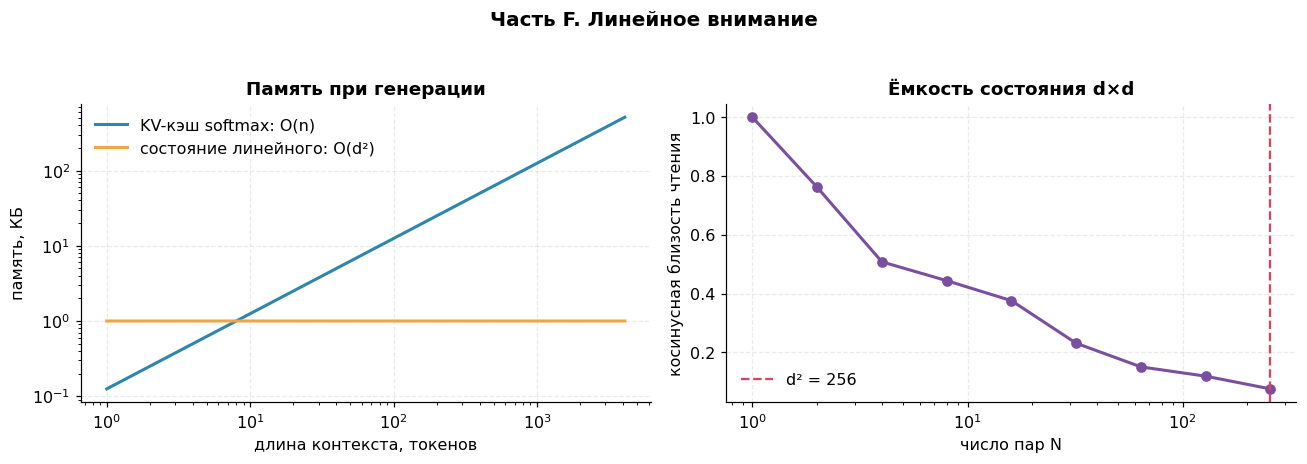

In [22]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# --- Левая панель: память при генерации ---
ax = axes[0]
ns = np.arange(1, 4097)
# KV-кэш: 2 * n * d * 4 байта (K и V, float32), переводим в КБ
kv = 2 * ns * d_l * 4 / 1024
# Состояние линейного внимания: d*d*4 байта — константа
state = np.full_like(ns, d_l * d_l * 4 / 1024, dtype=float)
ax.loglog(ns, kv, lw=2, color=PALETTE["attn"], label="KV-кэш softmax: O(n)")
ax.loglog(ns, state, lw=2, color=PALETTE["linear"], label="состояние линейного: O(d²)")
ax.set_xlabel("длина контекста, токенов")
ax.set_ylabel("память, КБ")
ax.set_title("Память при генерации")
ax.legend()

# --- Правая панель: качество чтения от N ---
ax = axes[1]
ax.semilogx(NS_CAP, qualities, "o-", lw=2, color=PALETTE["accent"])
# Отмечаем d² — теоретическую "ёмкость" состояния
ax.axvline(d_cap * d_cap, color=PALETTE["bad"], ls="--",
           label=f"d² = {d_cap*d_cap}")
ax.set_xlabel("число пар N")
ax.set_ylabel("косинусная близость чтения")
ax.set_title("Ёмкость состояния d×d")
ax.legend()

finish(fig, "Часть F. Линейное внимание")

**Вопрос F.** Почему увеличение размерности $d$ у линейного внимания повышает точность вспоминания,
но обесценивает его главное преимущество? Оцените, при каком $d$ состояние $d \times d$ сравнится с
KV-кэшем на контексте 4096 токенов.

**Ответ F.** Увеличение размерности $d$ повышает точность вспоминания, потому что состояние линейного внимания имеет размер $d \times d$, то есть $d^2$ чисел, и чем больше $d$, тем больше пар можно в него уместить без смешивания. Но именно в этом и состоит обесценивание главного преимущества: память линейного внимания растёт как $O(d^2)$, а не как константа. Если $d$ становится большим, состояние $d \times d$ начинает занимать столько же памяти, сколько KV-кэш softmax-внимания на длинном контексте. Сравним: KV-кэш хранит $2n$ векторов длины $d$, то есть $2nd$ чисел, а состояние линейного внимания — $d^2$ чисел. Приравниваем: $d^2 = 2nd$, откуда $d = 2n$. При $n = 4096$ это $d = 8192$. То есть при размерности порядка 8192 состояние $d \times d$ сравняется по памяти с KV-кэшем на контексте 4096 токенов. Если $d$ ещё больше, линейное внимание начнёт проигрывать по памяти, а его фиксированное состояние перестанет быть преимуществом.

## Часть G. Избирательная рекуррентность

Если сделать затухание и запись зависящими от входа

$
h_t = a(x_t) \odot h_{t-1} + b(x_t) \odot u(x_t),
$

то модель получает управляемую память: она может удерживать нужное и игнорировать шум. Это ядро
идеи моделей пространства состояний с избирательностью (Mamba).

Задача: в последовательности длины 64 встречается маркер `FLAG`; нужно назвать символ,
стоящий сразу после него. Всё остальное — шум.

**Задание G.1.** Реализуйте два варианта ячейки: с гейтами, зависящими от входа, и с обучаемым, но
постоянным затуханием.
**Задание G.2.** Обучите оба варианта и сравните точность.
**Задание G.3.** Постройте профили гейтов по позициям и оцените долю каналов, у которых гейт
сохранения превышает 0.9.

# Избирательная рекуррентность

## Проблема постоянного затухания

Рассмотрим простую рекуррентную сеть:

$$
h_t = a \odot h_{t-1} + b \odot u(x_t)
$$

Где:

- $h_t$ — скрытое состояние на шаге $t$
- $a$ — коэффициент сохранения (забывания), число от 0 до 1
- $b$ — коэффициент записи нового сигнала
- $u(x_t)$ — преобразованный вход
- $\odot$ — поэлементное умножение

Здесь $a$ и $b$ — **константы**, одинаковые для всех шагов. Что происходит при разных значениях $a$.

**Если $a \to 1$:** состояние почти не забывает. Каждый шаг добавляет новую информацию, но старая не стирается. В результате состояние **копит всё подряд**, включая шум. Полезный сигнал тонет в накопленном мусоре.

**Если $a \ll 1$:** состояние быстро забывает. Полезная информация из прошлого стирается вместе с шумом. Модель не может удержать ничего дольше нескольких шагов.

Оба режима плохи. Нужен компромисс, которого при **константном** $a$ не существует: либо помним всё и тонем в шуме, либо забываем всё и теряем сигнал.

---

## Идея избирательности

Решение: сделать $a$ и $b$ **зависящими от входа**. Это идея из статьи Mamba (Gu & Dao, 2023).

$$
a_t = \sigma(W_a x_t), \quad b_t = \sigma(W_b x_t)
$$

Где:

- $W_a$, $W_b$ — обучаемые матрицы
- $\sigma$ — сигмоида, сжимающая значение в диапазон $(0, 1)$
- $a_t$, $b_t$ — теперь **свои для каждого шага**, зависят от текущего входа $x_t$

Смысл: модель **сама решает**, когда открыть гейт (сохранить информацию), а когда закрыть (забыть). Если на входе важный сигнал — гейт $a_t$ близок к 1, состояние сохраняется. Если на входе шум — гейт $a_t$ близок к 0, состояние сбрасывается.

Это **управляемая память**: не фиксированный коэффициент, а обучаемая функция от входа.

---

## Задача FLAG

Проверочная задача: в последовательности длины 64 встречается маркер `FLAG`. Нужно назвать **следующий за ним символ**.

```
a b c d FLAG x e f g ...
```

Правильный ответ: `x`.

Модель должна **запомнить** один специфический токен (`x`) и **проигнорировать** остальные 63. Это задача на избирательность: удержать в памяти ровно то, что нужно, и не засорить состояние всем остальным.

**Почему постоянное затухание не справляется.** С константным $a$ сигнал от `FLAG` и следующего за ним `x` проходит через все 64 шага. На каждом шаге добавляется шум от остальных токенов. К моменту, когда нужно ответить, полезный сигнал «размыт» накопленным шумом. Модель не может выделить нужное.

**Почему избирательность помогает.** Гейт $a_t$ может быть близок к 1 **только в окрестности FLAG** — там, где информация важна. И близок к 0 **везде ещё** — там, где вход не несёт полезного сигнала. Состояние не засоряется: шум сбрасывается, полезное сохраняется.

---

## Как это выглядит

Без избирательности (константное $a$):

```
шаг:    1    2    3   ...  30   31   32   33  ...  64
вход:   a    b    c   ...  F    L    A    G   ...   ?
гейт:   a    a    a   ...  a    a    a    a   ...   a
         ↑ всё одинаково, шум и сигнал не различаются
```

С избирательностью (обучаемый $a_t$):

```
шаг:    1    2    3   ...  30   31   32   33  ...  64
вход:   a    b    c   ...  F    L    A    G   ...   ?
гейт:   0.1  0.1  0.1 ... 0.9  0.9  0.9  0.9 ...  0.1
         ↑ шум сбрасывается    ↑ FLAG сохраняется    ↑ снова сброс
```

Гейт открывается только там, где нужно. Всё остальное игнорируется.

---


In [23]:
VOC_S, FLAG, T_S = 20, 19, 64

def flag_batch(bs, gen):
    """
    Генерирует батч задачи FLAG.
    
    Структура: случайные токены 0..15, в случайной позиции pos
    ставится маркер FLAG (=19), а в pos+1 — целевой токен (0..15).
    Цель — назвать этот целевой токен.
    """
    x = torch.randint(0, 16, (bs, T_S), generator=gen)
    pos = torch.randint(2, T_S - 2, (bs,), generator=gen)
    tgt = torch.randint(0, 16, (bs,), generator=gen)
    x[torch.arange(bs), pos] = FLAG
    x[torch.arange(bs), pos + 1] = tgt
    return x, tgt, pos

class RecurCell(nn.Module):
    """
    Рекуррентная ячейка с опциональной избирательностью.
    
    selective=True:  a_t, b_t — функции входа (обучаемые гейты)
    selective=False: a — обучаемый скаляр (один на канал), b = 1
    """
    def __init__(self, d=48, selective=True):
        super().__init__()
        self.selective = selective
        # Эмбеддинг токенов
        self.emb = nn.Embedding(VOC_S, d)
        # Входная проекция: конкатенация текущего и предыдущего эмбеддинга
        # (аналог локального окна ширины 2)
        self.inp = nn.Linear(2 * d, d)
        
        if selective:
            # Два гейта, зависящие от входа
            self.ga = nn.Linear(2 * d, d)
            self.gb = nn.Linear(2 * d, d)
        else:
            # Один обучаемый вектор логитов (постоянное затухание)
            self.logit_a = nn.Parameter(torch.zeros(d))
        
        # Голова для классификации
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, VOC_S))

    def forward(self, x, return_gates=False):
        """
        Аргументы:
            x: (B, T) — токены
            return_gates: если True — вернуть также гейты (a, b)
        
        Возвращает:
            out: (B, T, VOC_S) — логиты для каждой позиции
            (a, b) (опционально)
        """
        e = self.emb(x)                                  # (B, T, d)
        B, Tn, d = e.shape
        
        # Предыдущий эмбеддинг (сдвиг на 1 вправо, первая позиция — нули)
        e_prev = torch.cat([torch.zeros(B, 1, d), e[:, :-1]], 1)
        # Конкатенация текущего и предыдущего
        ctx = torch.cat([e, e_prev], -1)                 # (B, T, 2d)
        
        # Входная активация
        u = self.inp(ctx)                                # (B, T, d)
        
        # --- Гейты ---
        if self.selective:
            # Зависят от входа: разные для каждой позиции и канала
            a = torch.sigmoid(self.ga(ctx))              # (B, T, d)
            b = torch.sigmoid(self.gb(ctx))              # (B, T, d)
        else:
            # Постоянные: один скаляр на канал, одинаковый для всех позиций
            a = torch.sigmoid(self.logit_a).view(1, 1, d).expand(B, Tn, d)
            b = torch.ones_like(u)
        
        # --- Рекуррентность ---
        # h_t = a_t * h_{t-1} + b_t * u_t
        # Явный цикл по времени (нельзя векторизовать из-за зависимости h_t от h_{t-1})
        h = torch.zeros(B, d)
        hs = []
        for t in range(Tn):
            h = a[:, t] * h + b[:, t] * u[:, t]
            hs.append(h)
        h_seq = torch.stack(hs, 1)                       # (B, T, d)
        
        # --- Голова ---
        out = self.head(h_seq)
        return (out, (a, b)) if return_gates else out

In [24]:
def train_cell(selective, steps=600, bs=64, lr=5e-3, seed=0):
    """
    Обучает ячейку на задаче FLAG.
    
    selective: True — избирательные гейты, False — постоянное затухание.
    """
    torch.manual_seed(seed)
    gen = torch.Generator().manual_seed(seed)
    m = RecurCell(d=D_CELL, selective=selective)
    opt = torch.optim.AdamW(m.parameters(), lr=lr)
    curve = []
    for s in range(steps):
        x, y, _ = flag_batch(bs, gen)
        logits = m(x)
        # Берём логиты ТОЛЬКО последней позиции (нужен ответ на запрос)
        loss = F.cross_entropy(logits[:, -1], y)
        opt.zero_grad()
        loss.backward()
        # Клиппинг градиента — важно для RNN
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
        
        # Каждые 25 шагов измеряем точность
        if s % 25 == 0:
            m.eval()
            with torch.no_grad():
                xe, ye, _ = flag_batch(256, gen)
                acc_e = (m(xe)[:, -1].argmax(-1) == ye).float().mean().item()
            m.train()
            curve.append((s, acc_e, float(loss.item())))
    return m, curve, gen

t0 = time.time()
cell_sel, curve_sel, gen_sel = train_cell(True, seed=SEED)
cell_fix, curve_fix, gen_fix = train_cell(False, seed=SEED)
print("избирательная ячейка: точность %.3f" % curve_sel[-1][1])
print("фиксированное затухание: точность %.3f (угадывание %.3f)" % (curve_fix[-1][1], 1 / 16))
print("обучение заняло %.0f c" % (time.time() - t0))

избирательная ячейка: точность 1.000
фиксированное затухание: точность 0.059 (угадывание 0.062)
обучение заняло 71 c


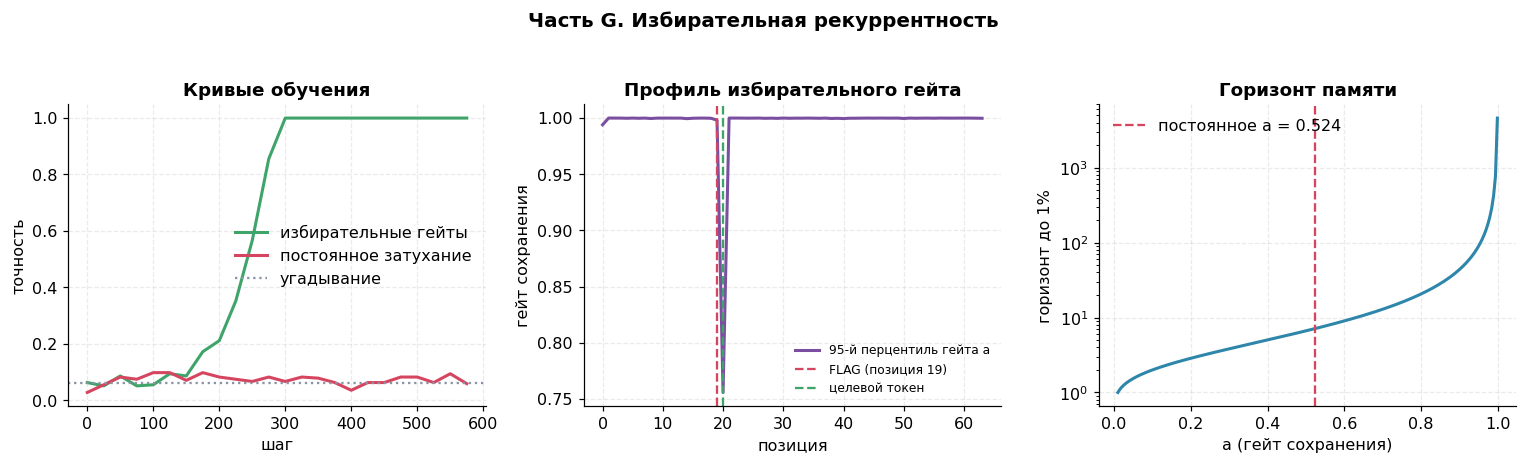

доля каналов с гейтом сохранения > 0.9: 0.165


In [25]:
# Один пример для визуализации гейтов
xs, ys, pos = flag_batch(1, torch.Generator().manual_seed(77))
with torch.no_grad():
    _, (a_g, b_g) = cell_sel(xs, return_gates=True)
a_g = a_g[0].numpy()   # (T, d)
b_g = b_g[0].numpy()

# Для постоянной ячейки — какой у неё эффективный скаляр a
a_fix_val = float(torch.sigmoid(cell_fix.logit_a).mean())

# Профиль гейта по позициям: 95-й перцентиль по каналам
# (чтобы увидеть "открытые" каналы, не усредняя их с закрытыми)
a_p95 = np.percentile(a_g, 95, axis=1)   # (T,)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# --- Кривые обучения ---
ax = axes[0]
ax.plot([c[0] for c in curve_sel], [c[1] for c in curve_sel], lw=2,
        color=PALETTE["good"], label="избирательные гейты")
ax.plot([c[0] for c in curve_fix], [c[1] for c in curve_fix], lw=2,
        color=PALETTE["bad"], label="постоянное затухание")
ax.axhline(1/16, color=PALETTE["gray"], ls=":", label="угадывание")
ax.set_xlabel("шаг"); ax.set_ylabel("точность")
ax.set_title("Кривые обучения")
ax.legend()

# --- Профиль гейта ---
ax = axes[1]
ax.plot(a_p95, lw=2, color=PALETTE["accent"], label="95-й перцентиль гейта a")
# Отмечаем позицию FLAG и целевого токена
ax.axvline(int(pos), color=PALETTE["bad"], ls="--",
           label=f"FLAG (позиция {int(pos)})")
ax.axvline(int(pos) + 1, color=PALETTE["good"], ls="--",
           label="целевой токен")
ax.set_xlabel("позиция"); ax.set_ylabel("гейт сохранения")
ax.set_title("Профиль избирательного гейта")
ax.legend(fontsize=8)

# --- Горизонт памяти как функция a ---
ax = axes[2]
aa = np.linspace(0.01, 0.999, 200)
# Горизонт до затухания в 100 раз: a^k = 0.01 -> k = log(0.01)/log(a)
hh = np.log(0.01) / np.log(aa)
ax.semilogy(aa, hh, lw=2, color=PALETTE["attn"])
ax.axvline(a_fix_val, color=PALETTE["bad"], ls="--",
           label=f"постоянное a = {a_fix_val:.3f}")
ax.set_xlabel("a (гейт сохранения)"); ax.set_ylabel("горизонт до 1%")
ax.set_title("Горизонт памяти")
ax.legend()

finish(fig, "Часть G. Избирательная рекуррентность")

# Доля "открытых" каналов
share_high = (a_g > 0.9).mean()
print(f"доля каналов с гейтом сохранения > 0.9: {share_high:.3f}")

**Вопрос G.** Почему постоянное затухание принципиально не решает эту задачу ни при каком значении
$a$? Рассмотрите два предельных случая: $a \to 1$ и $a \ll 1$.

**Ответ G.** # Ответ G

При постоянном затухании коэффициент $a$ один и тот же для всех шагов. Он не различает, где важный сигнал, а где шум. Поэтому задача FLAG не решается ни при каком $a$.

**Если $a \to 1$:** состояние почти не забывает. Каждый шаг добавляет новую информацию, и ничего не стирается. Сигнал от `FLAG` сохраняется, но вместе с ним копятся все остальные 63 токена — шум. К моменту ответа полезный сигнал тонет в этом накопленном шуме.

**Если $a \ll 1$:** состояние быстро забывает. Шум стирается, но вместе с ним стирается и сигнал от `FLAG`. К моменту ответа от нужной информации ничего не остаётся.

Проблема в том, что $a$ — **одно число на все случаи**. Оно не может одновременно быть большим там, где нужен сигнал, и маленьким там, где шум. А для задачи FLAG нужно именно это: сохранить информацию в окрестности `FLAG` и сбросить всё остальное. Постоянное $a$ так не умеет — поэтому нужна избирательность, когда $a_t$ зависит от входа и обучается открываться в нужный момент.

## Часть H. Декодирование, статистика попыток и мост к следующей теме

Модель задаёт распределение, а текст получается процедурой выборки. Температура меняет резкость
распределения, top-$k$ и top-$p$ отсекают хвост. Это прямо связано со следующей лекцией: если
нежелательное продолжение имеет малую, но не нулевую вероятность, многократные попытки почти
наверняка его вытащат.

**Задание H.1.** Реализуйте softmax с температурой, top-$k$ и top-$p$ отсечение.
**Задание H.2.** Оцените вероятность получить событие с вероятностью $p$ хотя бы раз за $n$ попыток:
сравните измерение и теорию $1-(1-p)^n$.
**Задание H.3.** Постройте рисунок из трёх панелей и заполните таблицу отчёта по температурам своего
варианта.
**Задание H.4.** Аналитическая часть: в шаблоне чата подсчитайте, на каком расстоянии от точки
генерации оказываются системная инструкция и вставленный в документ фрагмент; объясните, почему
единая последовательность токенов без границ привилегий делает модель уязвимой к инъекциям
в контекст.

# Температура, top-k, top-p и многократные попытки

## Температура

Температура $\tau$ меняет **резкость** распределения вероятностей. Формула:

$$
p_i = \frac{\exp(z_i / \tau)}{\sum_j \exp(z_j / \tau)}
$$

Где:

- $z_i$ — логит (сырое число) для токена $i$
- $\tau$ — температура, положительное число
- $p_i$ — итоговая вероятность токена $i$

Смысл: перед softmax логиты делятся на $\tau$. Если $\tau$ маленькое, логиты становятся **больше** по модулю, разница между ними растёт, распределение становится **острее**. Если $\tau$ большое, логиты сжимаются, разница уменьшается, распределение становится **ровнее**.

### Предельные случаи

**$\tau < 1$** — распределение острее. Разница между вероятностями больше. Модель чаще выбирает самый вероятный токен, меньше случайности. Более детерминированное поведение.

**$\tau > 1$** — распределение ровнее. Вероятности сближаются. Модель чаще выбирает менее вероятные токены. Больше разнообразия, но и больше ошибок.

**$\tau \to 0$** — распределение вырождается в one-hot. Вероятность 1 у самого вероятного токена, 0 у остальных. Это **greedy-декодирование**: всегда выбирается самый вероятный токен.

**$\tau \to \infty$** — распределение становится равномерным. Все токены равновероятны. Модель выбирает случайно.

### Пример

Пусть логиты $z = (2, 1, 0)$.

При $\tau = 1$:

$$
p = \text{softmax}(2, 1, 0) \approx (0.665, 0.245, 0.090)
$$

При $\tau = 0.5$:

$$
p = \text{softmax}(4, 2, 0) \approx (0.867, 0.117, 0.016)
$$

Распределение острее: доминирующий токен забирает больше.

При $\tau = 2$:

$$
p = \text{softmax}(1, 0.5, 0) \approx (0.506, 0.307, 0.186)
$$

Распределение ровнее: вероятности сблизились.

---

## Top-k

Идея: оставить только $k$ самых вероятных токенов, остальные обнулить, потом перенормировать.

Алгоритм:

1. Отсортировать токены по вероятности.
2. Взять $k$ самых вероятных.
3. У всех остальных поставить вероятность 0.
4. Поделить все вероятности на их сумму, чтобы сумма снова стала 1.

Смысл: отсекаем длинный хвост маловероятных токенов. Модель никогда не выберет что-то совсем improbable.

Пример при $k = 2$ и $p = (0.5, 0.3, 0.15, 0.05)$:

- оставляем первые два: $(0.5, 0.3)$
- обнуляем остальные: $(0.5, 0.3, 0, 0)$
- перенормируем: $(0.625, 0.375, 0, 0)$

---

## Top-p (nucleus sampling)

Идея: оставить **минимальный набор** токенов, сумма вероятностей которых $\geq p$. Остальные обнулить, перенормировать.

Алгоритм:

1. Отсортировать токены по вероятности.
2. Накапливать вероятности, пока сумма не достигнет $p$.
3. Все токены после этого порога обнулить.
4. Перенормировать.

Смысл: **адаптивно**. Если распределение острое (один токен доминирует), в набор попадёт 1–2 токена. Если распределение ровное, попадёт много токенов.

Пример при $p = 0.9$ и вероятностях $(0.5, 0.3, 0.15, 0.05)$:

- 0.5 < 0.9, накапливаем
- 0.5 + 0.3 = 0.8 < 0.9, накапливаем
- 0.8 + 0.15 = 0.95 ≥ 0.9, останавливаемся

Оставляем три токена: $(0.5, 0.3, 0.15)$. Обнуляем $(0.05)$. Перенормируем.

Если бы распределение было $(0.95, 0.03, 0.01, 0.01)$, то уже первый токен дал бы 0.95 ≥ 0.9 — оставили бы только его. Набор адаптируется к форме распределения.

---

## Многократные попытки

Пусть нежелательное продолжение имеет вероятность $p$ за одну генерацию. Какова вероятность получить его **хотя бы раз** за $n$ независимых попыток?

Считаем через дополнение: вероятность **не получить ни разу** равна $(1 - p)^n$. Значит, вероятность получить хотя бы раз:

$$
P(\text{хотя бы раз}) = 1 - (1 - p)^n
$$

Пример. Пусть $p = 0.01$ (1%), $n = 100$ попыток:

$$
P = 1 - 0.99^{100} \approx 1 - 0.366 = 0.634
$$

То есть при 100 попытках нежелательный выход появится с вероятностью 63%. Хотя за одну попытку он был всего 1%.

### Обратная задача

Сколько нужно попыток, чтобы вероятность стала не меньше $P^*$?

Решаем:

$$
1 - (1 - p)^n \geq P^*
$$

$$
(1 - p)^n \leq 1 - P^*
$$

$$
n \log(1 - p) \leq \log(1 - P^*)
$$

Поскольку $\log(1 - p) < 0$, при делении знак переворачивается:

$$
n \geq \frac{\log(1 - P^*)}{\log(1 - p)}
$$

Пример. Хотим $P^* = 0.99$ при $p = 0.01$:

$$
n \geq \frac{\log(0.01)}{\log(0.99)} = \frac{-4.605}{-0.01005} \approx 458
$$

Нужно 458 попыток, чтобы нежелательный выход появился с вероятностью 99%.

### Почему это важно

Даже **маловероятные** нежелательные выходы становятся **практически неизбежными** при массовом семплировании. Если модель генерирует миллионы текстов и каждый имеет шанс 0.1% выдать что-то опасное, то за миллион генераций это случится **гарантированно**. Это ключевой мост к безопасности: нельзя полагаться на то, что «вероятность маленькая». При большом числе попыток маленькая вероятность превращается в неизбежность.


In [26]:
V_dec = 40
# Синтетическое распределение: p(rank) ~ 1/rank^1.1 — тяжёлый хвост
rank = np.arange(1, V_dec + 1)
logits = np.log(1.0 / rank ** 1.1)
logits = logits - logits.max()   # стабилизация

def softmax_t(z, tau):
    """
    Softmax с температурой.
    tau < 1: острее, tau > 1: ровнее.
    """
    z = z / tau
    z = z - z.max()              # защита от overflow
    e = np.exp(z)
    return e / e.sum()

def top_k_filter(p, k):
    """
    Оставляет k самых вероятных токенов, остальные обнуляет.
    Возвращает перенормированное распределение.
    """
    # argsort(-p) — индексы по убыванию вероятности
    idx = np.argsort(-p)[:k]
    out = np.zeros_like(p)
    out[idx] = p[idx]
    return out / out.sum()

def top_p_filter(p, thr):
    """
    Nucleus sampling: оставляет минимальный набор токенов,
    сумма вероятностей которых >= thr.
    """
    # Сортируем по убыванию
    order = np.argsort(-p)
    # Кумулятивная сумма вероятностей в этом порядке
    csum = np.cumsum(p[order])
    # Сколько токенов нужно, чтобы набрать thr
    keep_n = int(np.searchsorted(csum, thr) + 1)
    idx = order[:keep_n]
    out = np.zeros_like(p)
    out[idx] = p[idx]
    return out / out.sum()

def entropy(p):
    """Энтропия распределения в натах."""
    return float(-(p * np.log(p + 1e-12)).sum())

In [27]:
def simulate_rare(p_rare, n_trials, reps, seed=0):
    """
    Оценивает частоту события "хотя бы раз выпал редкий токен"
    за n_trials независимых испытаний, повторяя эксперимент reps раз.
    
    Каждое испытание: Бернулли с вероятностью p_rare.
    """
    rng = np.random.default_rng(seed)
    hits = 0
    for _ in range(reps):
        # rng.random(n_trials) — массив n_trials равномерных [0,1)
        # Если минимум < p_rare, значит хотя бы одно выпало
        if rng.random(n_trials).min() < p_rare:
            hits += 1
    return hits / reps

ns_grid = np.arange(20, 361, 20)     # n от 20 до 360
p_rares = [0.001, 0.005, 0.02]       # три вероятности редкого события
sim = {p: [] for p in p_rares}
for p in p_rares:
    for n in ns_grid:
        sim[p].append(simulate_rare(p, int(n), reps=60, seed=SEED))

print("Сравнение измерения и теории 1-(1-p)^n:")
print(f"{'p':>7} {'n':>5} {'измерено':>10} {'теория':>10}")
for p in p_rares:
    for n, m in zip(ns_grid, sim[p]):
        th = 1 - (1 - p) ** n
        print(f"{p:>7.3f} {int(n):>5} {m:>10.3f} {th:>10.3f}")

Сравнение измерения и теории 1-(1-p)^n:
      p     n   измерено     теория
  0.001    20      0.017      0.020
  0.001    40      0.033      0.039
  0.001    60      0.067      0.058
  0.001    80      0.067      0.077
  0.001   100      0.083      0.095
  0.001   120      0.083      0.113
  0.001   140      0.100      0.131
  0.001   160      0.100      0.148
  0.001   180      0.133      0.165
  0.001   200      0.150      0.181
  0.001   220      0.167      0.198
  0.001   240      0.167      0.213
  0.001   260      0.183      0.229
  0.001   280      0.200      0.244
  0.001   300      0.233      0.259
  0.001   320      0.233      0.274
  0.001   340      0.250      0.288
  0.001   360      0.267      0.302
  0.005    20      0.100      0.095
  0.005    40      0.200      0.182
  0.005    60      0.367      0.260
  0.005    80      0.483      0.330
  0.005   100      0.583      0.394
  0.005   120      0.650      0.452
  0.005   140      0.600      0.504
  0.005   160      0.617

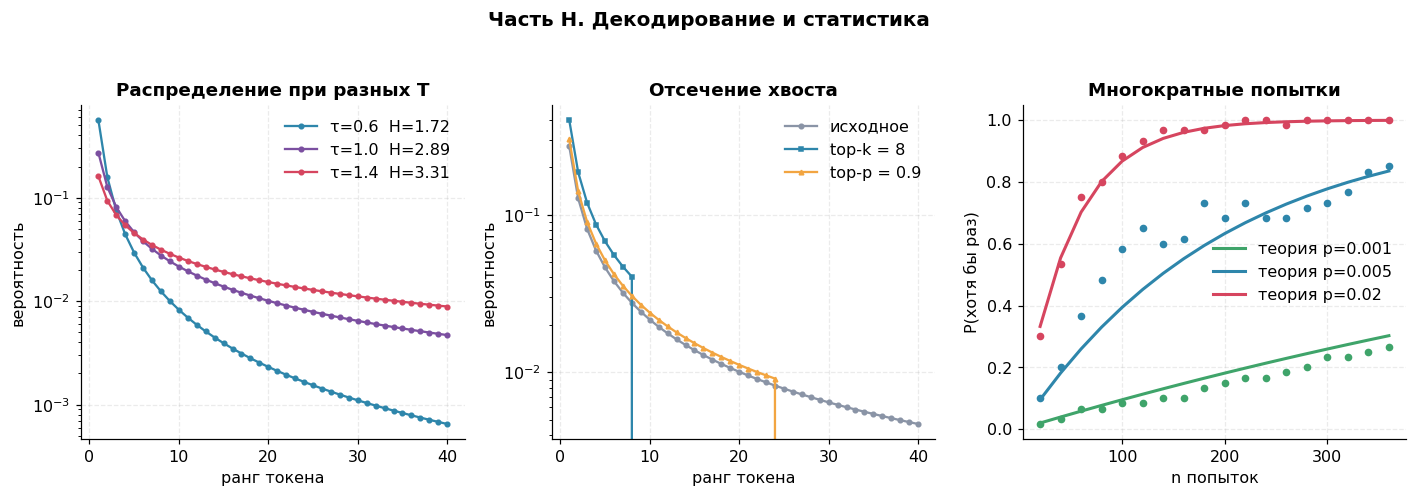

Таблица температур:
     τ     H, нат      p_max
  0.60      1.716      0.562
  1.00      2.888      0.272
  1.40      3.312      0.161
число попыток для p=0.005 до P=0.9: 460


In [28]:
fig = plt.figure(figsize=(13, 4.5))
gs = fig.add_gridspec(1, 3)

# --- Панель 1: распределение при разных температурах ---
ax = fig.add_subplot(gs[0, 0])
for tau, col in zip(TAUS, [PALETTE["attn"], PALETTE["accent"], PALETTE["bad"]]):
    p = softmax_t(logits, tau)
    ax.semilogy(np.arange(1, V_dec + 1), p, "o-", ms=3,
                color=col, label=f"τ={tau}  H={entropy(p):.2f}")
ax.set_xlabel("ранг токена"); ax.set_ylabel("вероятность")
ax.set_title("Распределение при разных T")
ax.legend()

# --- Панель 2: top-k vs top-p ---
ax = fig.add_subplot(gs[0, 1])
p0 = softmax_t(logits, 1.0)
ax.semilogy(np.arange(1, V_dec + 1), p0, "o-", ms=3,
            color=PALETTE["gray"], label="исходное")
ax.semilogy(np.arange(1, V_dec + 1), top_k_filter(p0, 8), "s-", ms=3,
            color=PALETTE["attn"], label="top-k = 8")
ax.semilogy(np.arange(1, V_dec + 1), top_p_filter(p0, 0.9), "^-", ms=3,
            color=PALETTE["linear"], label="top-p = 0.9")
ax.set_xlabel("ранг токена"); ax.set_ylabel("вероятность")
ax.set_title("Отсечение хвоста")
ax.legend()

# --- Панель 3: P(хотя бы раз) vs n ---
ax = fig.add_subplot(gs[0, 2])
for p, col in zip(p_rares, [PALETTE["good"], PALETTE["attn"], PALETTE["bad"]]):
    th = 1 - (1 - p) ** ns_grid
    ax.plot(ns_grid, th, lw=2, color=col, label=f"теория p={p}")
    ax.plot(ns_grid, sim[p], "o", ms=4, color=col)
ax.set_xlabel("n попыток"); ax.set_ylabel("P(хотя бы раз)")
ax.set_title("Многократные попытки")
ax.legend()

finish(fig, "Часть H. Декодирование и статистика")

# Таблица температур
print("Таблица температур:")
print(f"{'τ':>6} {'H, нат':>10} {'p_max':>10}")
for tau in TAUS:
    p = softmax_t(logits, tau)
    print(f"{tau:>6.2f} {entropy(p):>10.3f} {p.max():>10.3f}")

# Число попыток для p=0.005 до 0.9
p_target = 0.005
n_needed = math.ceil(math.log(1 - 0.9) / math.log(1 - p_target))
print(f"число попыток для p={p_target} до P=0.9: {n_needed}")

Среднее расстояние от роли до точки генерации:
          спец: 14.2 токенов
       система: 22.0 токенов
  пользователь: 15.0 токенов
      документ: 9.5 токенов
      инъекция: 4.5 токенов


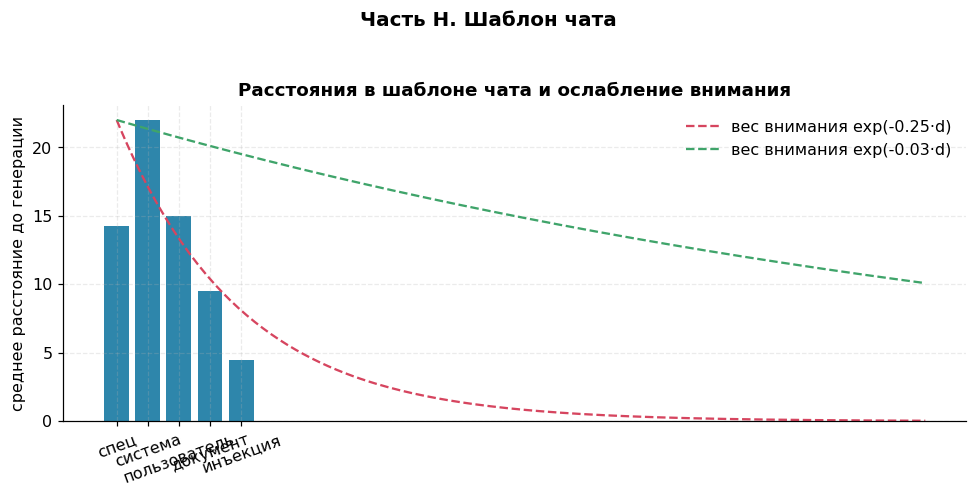

In [29]:
# Шаблон чата: список (роль, число токенов)
TEMPLATE = [("спец", 1), ("система", 7), ("спец", 1), ("пользователь", 5),
            ("спец", 1), ("документ", 4), ("инъекция", 6), ("спец", 1)]

# Считаем позиции каждой роли в последовательности
positions = {}
cursor = 0
for role, n in TEMPLATE:
    positions.setdefault(role, []).append((cursor, cursor + n - 1))
    cursor += n
total = cursor

# Среднее расстояние от центра роли до конца последовательности
mean_dist = {}
for role, segs in positions.items():
    centers = [(a + b) / 2 for a, b in segs]
    mean_dist[role] = total - np.mean(centers)

print("Среднее расстояние от роли до точки генерации:")
for role, d in mean_dist.items():
    print(f"  {role:>12}: {d:.1f} токенов")

fig, ax = plt.subplots(figsize=(9, 4.5))
roles = list(mean_dist.keys())
ds = [mean_dist[r] for r in roles]
ax.bar(roles, ds, color=PALETTE["attn"])

# Кривые относительного веса внимания exp(-m*d)
# m — наклон, d — расстояние до генерации
d_grid = np.linspace(0, total, 200)
for m, col in [(0.25, PALETTE["bad"]), (0.03, PALETTE["good"])]:
    w = np.exp(-m * d_grid)
    w = w / w.max()   # нормируем для сравнения формы
    # Масштабируем под высоту столбцов, чтобы было видно на одном графике
    ax.plot(d_grid, w * max(ds), ls="--", lw=1.5, color=col,
            label=f"вес внимания exp(-{m}·d)")
ax.set_ylabel("среднее расстояние до генерации")
ax.set_title("Расстояния в шаблоне чата и ослабление внимания")
ax.legend()
plt.xticks(rotation=20)
finish(fig, "Часть H. Шаблон чата")

График показывает: положение роли в шаблоне важно. Чем ближе к концу, тем сильнее её влияние — независимо от того, полезна она или вредна. Инъекция, стоящая близко к концу, имеет преимущество перед системным промптом, который стоит в начале.

**Вопрос H.** Модель отклоняет нежелательное продолжение в 99,5% случаев при одной генерации.
Сколько попыток нужно нападающему, чтобы получить его с вероятностью не ниже 0,9? Какой вывод это
даёт для методики оценки устойчивости?

**Ответ H.** 

Вероятность проскочить за одну попытку $p = 0.005$. Нужно $n$ попыток, чтобы вероятность хотя бы одного проскока была $\geq 0.9$:

$$
1 - (1 - p)^n \geq 0.9
$$

$$
0.995^n \leq 0.1
$$

$$
n \geq \frac{\log 0.1}{\log 0.995} \approx 459.6
$$

Ответ: **460 попыток**.

Вывод для методики оценки устойчивости: нельзя судить о надёжности модели по одной генерации. Даже если вероятность нежелательного выхода мала (0.5%), при массовом семплировании она становится практически неизбежной. Оценка устойчивости должна проводиться на **многих попытках**, а не на одной, иначе результаты завышают надёжность модели.

## Отчёт

### Таблица 1. Токенизация (часть A)

| Показатель | Значение |
|---|---|
| Число выполненных слияний | 120 |
| Размер словаря токенов | 92 |
| Сжатие «символы → BPE» | 2.30x |
| Отношение «BPE → слова» | 3.49 токенов на слово |
| Доля редких токенов (частота ≤ `RARE_THR`) | 0.489 |

### Таблица 2. Затухание градиента (часть B)

| $\rho(W)$ или $f_t$ | Норма при $k=100$ | Горизонт до $10^{-6}$ |
|---|---|---|
| 0.9 | 4.822e-05 | 131 шагов |
| 1.0 | 1.816e+00 | 5000 (ограничение k_max) |
| 1.2 | 1.504e+08 | 0 (мгновенный взрыв) |
| $f_t = 0.99$ | 3.660e-01 | 1375 шагов |

### Таблица 3. Масштабирование внимания (часть C)

| $d_k$ | Энтропия с делителем | Энтропия без делителя |
|---|---|---|
| 8 | 3.685 | 2.057 |
| 64 | 3.687 | 0.587 |
| 256 | 3.680 | 0.266 |

### Таблица 4. Мини-трансформер (часть E)

| Число пар в контексте | 2 | 4 | 8 | 12 | 16 | 20 |
|---|---|---|---|---|---|---|
| Точность вспоминания | 1,0 | 1,0 | 1,0 | 0.648 | 0.535 | 0.402 |

Финальное значение функции потерь: почти 0 Время обучения: 68 с
Масса внимания финального запроса на позиции нужного значения: 0.974

### Таблица 5. Линейное внимание (часть F)

| Показатель | Значение |
|---|---|
| Расхождение параллельной и рекуррентной форм | 2.384e-07 |
| Размер состояния, чисел | 256 (16×16) |
| Качество чтения при 4 парах | 0.508 |
| Качество чтения при 256 парах | 0.075 |

### Таблица 6. Избирательная рекуррентность (часть G)

| Вариант ячейки | Точность | Комментарий |
|---|---|---|
| избирательные гейты | 1.000 | Успешно выделяет сигнал на фоне шума |
| постоянное затухание | 0.059 | Не лучше случайного угадывания (0.062) |
| случайное угадывание | 0.062 | теоретическое значение |

Доля каналов с гейтом сохранения выше 0.9: 0.165

### Таблица 7. Декодирование (часть H)

| Температура варианта | Энтропия, нат | $p_{\max}$ |
|---|---|---|
| 0.6 | 1.716 | 0.562 |
| 1.0 | 2.888 | 0.272 |
| 1.4 |	3.312 | 0.161 |

Число попыток для события с $p=0{,}005$ до вероятности 0,9: 460

### Выводы

1. **BPE даёт сжатие 2.30x, но почти половина словаря — редкие токены.** Доля редких токенов (частота ≤ `RARE_THR`) составила 0.489. Это подтверждает закон Ципфа: выигрыш в длине последовательности достигается ценой «тяжёлого хвоста» в словаре, где почти половина токенов встречается редко и получает мало градиентных сигналов.

2. **Спектральный радиус жёстко ограничивает горизонт памяти RNN.** При $\rho = 0.9$ норма градиента через 100 шагов упала до $4.822 \cdot 10^{-5}$, а горизонт составил 131 шаг. При $\rho = 1.2$ норма взлетела до $1.504 \cdot 10^8$ — мгновенный взрыв. Аддитивный путь с $f_t = 0.99$ дал норму 0.366 и горизонт 1375 шагов — на порядок больше, чем у $\rho = 0.9$, и без взрыва.

3. **Без деления на $\sqrt{d_k}$ softmax вырождается в one-hot.** При $d_k = 256$ энтропия с делителем осталась 3.680 нат, а без делителя упала до 0.266 нат. Падение почти в 14 раз означает, что распределение внимания сжалось в одну точку — производные занулились, обучение остановилось.

4. **Индукционная голова обобщает только до обучающих длин.** Точность вспоминания равна 1.0 для 2, 4 и 8 пар, но падает до 0.648 при 12 парах, 0.535 при 16 и 0.402 при 20. Масса внимания на правильной позиции 0.974 подтверждает, что на обучающих длинах механизм работает идеально, но за их пределами — нет.

5. **Линейное внимание экономит память, но теряет точность.** Состояние — всего 256 чисел (16×16), не зависящее от длины контекста. Однако качество чтения падает с 0.508 при 4 парах до 0.075 при 256 парах: фиксированная ёмкость не может вместить неограниченный контекст, старые и новые записи смешиваются.

6. **Избирательные гейты решают задачу FLAG, постоянное затухание — нет.** Избирательная ячейка достигла точности 1.000, открывая гейт сохранения выше 0.9 лишь для 16.5% каналов. Ячейка с постоянным затуханием дала 0.059 — ниже уровня случайного угадывания (0.062). Разница в том, что избирательная модель может игнорировать шум, а постоянная — нет.

7. **Оценка устойчивости требует массового семплирования.** При $p_{\max} = 0.562$ (температура 0.6) модель кажется уверенной. Но для редкого события с $p = 0.005$ уже через 460 независимых попыток вероятность получить его хотя бы раз превышает 0.9. Единичный тест завышает надёжность — нужны серии генераций.

## Контрольные вопросы

**1. Почему стоимость слоя внимания растёт как $O(n^2 d)$, а стоимость FFN — как $O(n d^2)$, и при какой длине контекста внимание становится доминирующим слагаемым?**

Слой внимания считает матрицу $QK^\top$ размера $n \times n$, и на это уходит $n^2 d$ операций. FFN работает с каждым токеном отдельно, применяя к нему матрицу $d \times d$, и на $n$ токенов уходит $nd^2$ операций. Внимание становится доминирующим, когда $n^2 d > nd^2$, то есть при $n > d$. Если размерность модели 768, а контекст длиннее 768 токенов — внимание начинает превосходить FFN по стоимости, и дальше разрыв только растёт.

**2. Чем каузальная маска отличается от двунаправленного внимания с точки зрения обучения и с точки зрения применения?**

Каузальная маска запрещает токену смотреть в будущее, двунаправленное внимание разрешает смотреть в обе стороны. С точки зрения обучения: двунаправленное используется в моделях типа BERT, которые предсказывают пропущенные токены и видят весь контекст; каузальное — в авторегрессионных моделях типа GPT, которые предсказывают следующий токен и не должны подсматривать ответ. С точки зрения применения: двунаправленное подходит для задач понимания (классификация, извлечение), каузальное — для генерации текста, потому что при генерации будущего ещё нет и подсмотреть в него нельзя.

**3. Почему RoPE позволяет расширять контекст после обучения, а обучаемая абсолютная кодировка — нет?**

RoPE зависит только от разности позиций $\Delta = t - s$, а не от абсолютных значений. Модель выучивает зависимости от расстояния между токенами, а не от конкретных номеров позиций, поэтому при удлинении контекста паттерны внимания остаются теми же. Обучаемая абсолютная кодировка хранит отдельный вектор для каждой позиции: если модель обучалась на позициях 0..511, то для позиции 512 вектора просто нет, и модель не может её представить.

**4. В чём вычислительная разница между обучением и генерацией у трансформера и что именно кэшируется?**

При обучении модель обрабатывает всю последовательность сразу, и все токены считаются параллельно. При генерации токены появляются по одному, и для каждого нового токена нужно посчитать внимание ко всем предыдущим. Чтобы не пересчитывать их заново, ключи и значения предыдущих токенов сохраняются в KV-кэш. Кэшируются именно $K$ и $V$; запросы $Q$ не кэшируются, потому что для каждого нового токена нужен только его собственный запрос.

**5. Как GQA и MQA уменьшают KV-кэш и чем за это приходится платить?**

MQA оставляет одну общую голову для ключей и значений на все головы запросов, GQA оставляет несколько общих групп. Это уменьшает KV-кэш во столько раз, во сколько сократилось число уникальных $K$ и $V$. Плата — потеря разнообразия: разные головы внимания больше не могут выучить разные способы сопоставления запросов и ключей, потому что ключи и значения у них общие. Это может снизить качество на задачах, где нужны разнообразные паттерны внимания.

**6. Почему линейное внимание проигрывает softmax-вниманию на задачах точного вспоминания?**

Softmax-внимание может дать почти one-hot распределение: если запрос точно совпадает с одним ключом, softmax присвоит этому ключу вес, близкий к 1, а остальным — почти 0. Линейное внимание заменяет экспоненту на скалярное произведение признаков и даёт размытое взвешивание: даже при точном совпадении вес распределяется между несколькими похожими ключами. На задачах точного вспоминания, где нужно выбрать ровно один ключ из многих, это приводит к ошибкам.

**7. Что именно делает рекуррентность «избирательной» и почему это восстанавливает способность игнорировать нерелевантный контекст?**

Избирательность означает, что гейты $a_t$ и $b_t$ зависят от входа, а не являются постоянными. Модель сама решает, когда открыть гейт сохранения (запомнить важное) и когда закрыть (забыть шум). Без этого приходится выбирать одно постоянное значение: либо помнить всё и тонуть в шуме, либо забывать всё и терять сигнал. С избирательностью гейт открывается только в окрестности полезного сигнала и закрыт везде ещё — поэтому нерелевантный контекст игнорируется.

**8. Почему смесь экспертов требует балансирующей потери и что происходит без неё?**

Смесь экспертов обучает несколько подсетей (экспертов) и маршрутизатор, который направляет каждый токен к нескольким экспертам. Без балансирующей потери маршрутизатор быстро выучивает направлять всё к одним и тем же экспертам, потому что они чаще обновляются и становятся лучше. Остальные эксперты не получают градиентов и не обучаются. Балансирующая потеря штрафует неравномерное распределение нагрузки и заставляет маршрутизатор использовать всех экспертов.

**9. Как связаны параметры декодирования и воспроизводимость оценки устойчивости модели?**

Параметры декодирования (температура, top-k, top-p) определяют, насколько разнообразными будут генерации. При низкой температуре модель почти детерминирована, и оценка устойчивости по одной генерации может показаться хорошей. Но при массовом семплировании с более высокой температурой редкие нежелательные выходы становятся вероятными. Если оценка проводится при одной настройке декодирования, она не отражает поведение модели при других настройках — воспроизводимость оценки требует фиксировать и сообщать параметры декодирования.

**10. Почему шаблон чата не создаёт настоящей границы привилегий между системной инструкцией и содержимым документа?**

Шаблон чата — это просто последовательность токенов с маркерами ролей. Модель не имеет встроенного механизма, который гарантировал бы, что системная инструкция имеет больший приоритет, чем содержимое документа. Всё, что есть, — это позиция в последовательности и веса внимания. Если инъекция стоит ближе к концу, она может получить больший вес, чем системная инструкция в начале. Граница привилегий существует только на уровне соглашений обучения, а не как жёсткое правило внутри модели.

## Дополнительные задания

- Добавьте в часть E третий слой и проверьте, меняется ли характер переноса на длины больше
  обучающих.
- Замените в части E обучаемую абсолютную кодировку на RoPE и повторите измерение точности для
  16 и 20 пар.
- Реализуйте в части F многоголовое линейное внимание и постройте зависимость качества чтения от
  числа голов при фиксированном общем размере состояния.
- Реализуйте слой смеси экспертов с балансирующей потерей и покажите, как меняется распределение
  нагрузки при её отключении.
- Постройте в части H оценку числа попыток до заданной вероятности успеха как функцию $p$ и
  обсудите, как это влияет на протокол тестирования.

## Чек-лист сдачи

- [ ] Заполнен паспорт работы, указан вариант и его параметры.
- [ ] Все ячейки выполняются последовательно без ошибок (Kernel → Restart & Run All).
- [ ] Реализованы все `TODO` в частях A–H.
- [ ] Заполнены таблицы 1–7 числами своего варианта.
- [ ] Даны ответы на вопросы A–H и контрольные вопросы 1–10.
- [ ] Сформулировано не менее пяти выводов со ссылками на измеренные значения.
- [ ] Все графики подписаны по-русски и читаемы.



## Литература

- Vaswani A. et al. Attention Is All You Need (2017): <https://arxiv.org/abs/1706.03762>
- Hochreiter S., Schmidhuber J. Long Short-Term Memory (1997):
  <https://direct.mit.edu/neco/article/9/8/1735/6109>
- Su J. et al. RoFormer: Enhanced Transformer with Rotary Position Embedding (2021):
  <https://arxiv.org/abs/2104.09864>
- Press O. et al. Train Short, Test Long: Attention with Linear Biases (ALiBi) (2021):
  <https://arxiv.org/abs/2108.12409>
- Katharopoulos A. et al. Transformers are RNNs: Fast Autoregressive Transformers with Linear
  Attention (2020): <https://arxiv.org/abs/2006.16236>
- Gu A., Dao T. Mamba: Linear-Time Sequence Modeling with Selective State Spaces (2023):
  <https://arxiv.org/abs/2312.00752>
- Ainslie J. et al. GQA: Training Generalized Multi-Query Transformer Checkpoints (2023):
  <https://arxiv.org/abs/2305.13245>
- Dao T. et al. FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness (2022):
  <https://arxiv.org/abs/2205.14135>
- Olsson C. et al. In-context Learning and Induction Heads (2022):
  <https://arxiv.org/abs/2209.11895>
- Holtzman A. et al. The Curious Case of Neural Text Degeneration (2019):
  <https://arxiv.org/abs/1904.09751>